In [33]:
# %matplotlib inline
# !pip install --upgrade matplotlib
%pip install ipympl

     |████████████████████████████████| 511 kB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 139 kB 66.2 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 93.6 MB/s eta 0:00:01
     |████████████████████████████████| 914 kB 141.1 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


# Cosserat Rod Centerline — Sub-pixel Pipeline (v2)

Replaces the skeletonization approach from `skeletonization.ipynb` with **sub-pixel
edge midpoint detection** — the same algorithm as `ros_centerline_3.py`, applied
offline to a recorded `.avi`.

### Why sub-pixel instead of skeleton?

The skeletonization approach produces a **staircase pixel path**: the skeleton lives
on integer pixel coordinates. Diagonal hops cost √2 and axis-aligned hops cost 1, so
a vertical rod and a tilted rod of the same physical length produce different apparent
arc lengths — orientation-dependent arc-length bias of ~11 mm std / 79 mm range
(see comments in `ros_centerline_2.py` lines 430–438).

The sub-pixel approach:
1. **Scan along the dominant axis** (row-by-row if rod is more vertical, col-by-col if
   more horizontal) — always maximises the number of samples.
2. At each scanline, find both rod edges via **sub-pixel quadratic interpolation** of
   the Sobel gradient peak.
3. **Centreline = midpoint of the two edges** — a float coordinate, not grid-snapped.
4. Fit a cubic spline to the float centreline points, resample to N_OUT=25 equidistant
   nodes.

This is exactly the fix described in the game-dev staircase thread:
> *"adjust the minor axis to follow the trajectory slope rather than rounding
independently"*.

### Pipeline
1. Config
2. Load video + ROI / frame-range selection
3. Per-frame: threshold → largest component → morphological clean → sub-pixel centreline
4. Clamp anchoring + orientation (clamp→tip)
5. Save to `.mat` (compatible with `cosserat_GPR_pipeline_real_data.m`)
6. Diagnostics: arc-length per frame, tip-jump, 3-D surface plots

## Step 1 — Configuration

Set all paths, physical parameters, and detection settings here.
Everything downstream reads from this cell.

In [207]:
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from scipy.io import savemat
import os, subprocess, tempfile, warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi']     = 100
matplotlib.rcParams['figure.figsize'] = (10, 4)

# ── Paths ─────────────────────────────────────────────────────────────────
VIDEO_PATH     = '../../../../cosserat_rod_data/videos/video_0.avi'
# VIDEO_PATH     = '../../../Data/Real_data/raw_videos/video_1_rec.avi'
# OUT_MAT        = 'Processed_videos/cosserat_real_data.mat'
OUT_MAT        = 'Processed_data/cosserat_real_data.mat'
OUT_VIDEO_H264 = 'Processed_videos/centerline_subpixel_h264.mp4'
OUT_ARC_CSV    = 'Processed_data/arc_length_per_frame.csv'

# ── Rod discretisation ────────────────────────────────────────────────────
N_OUT = 26        # output centreline points per frame

# ── Physical parameters  (must be set manually) ───────────────────────────
L0  = 0.28         # rod physical length (m)
b   = 5e-3         # cross-section thickness — out-of-plane, perpendicular to camera (m)
h   = 10e-3        # cross-section width    — in-plane, camera-facing (m)
A   = b * h        # rectangular cross-section area (m²)
I   = h * b**3 / 12  # weak-axis bending: camera sees h face, bends about h axis (m⁴)
rho = 2428.6       # density (kg/m³) — derived: m/(A*L0) = 0.034/(5e-5*0.27)

# ── Frame range ───────────────────────────────────────────────────────────
# FRAME_START: skip the first N frames (e.g. before the rod starts moving).
# FRAME_END  : set to an integer to stop early, or None to process until end.
FRAME_START = 0
FRAME_END   = None   # auto-filled from video in Step 1b

# ── ROI  (x1, y1, x2, y2) or None for full frame ─────────────────────────
ROI = None

# ── Detection parameters ──────────────────────────────────────────────────
THRESH_VAL    = 130    # binary threshold (rod brighter than background)
INVERT_THRESH = False  # True if rod is darker than background
MORPH_CLOSE_K = 7
MORPH_OPEN_K  = 5
MIN_SCANLINE_PTS = 10
SPLINE_SMOOTH_K  = 0.5

# ── Clamp / tip stability ─────────────────────────────────────────────────
MAX_CLAMP_DIST_PX = 80

# ── Auto-calibrated values (filled by Step 1b — do not edit manually) ─────
FPS              = None   # Hz         — from video metadata
PIXELS_PER_METRE = None   # px/m       — from sub-pixel arc / L0
CLAMP_PX         = None   # [x, y] px  — from lowest-variance point

print('Config loaded. Run Step 1b to auto-calibrate FPS, PIXELS_PER_METRE, CLAMP_PX.')
print(f'  L0={L0} m  b={b*1e3:.1f}mm x h={h*1e3:.1f}mm  A={A:.4e} m²  I={I:.4e} m⁴')
print(f'  FRAME_START={FRAME_START}  THRESH={THRESH_VAL}')


Config loaded. Run Step 1b to auto-calibrate FPS, PIXELS_PER_METRE, CLAMP_PX.
  L0=0.28 m  b=5.0mm x h=10.0mm  A=5.0000e-05 m²  I=1.0417e-10 m⁴
  FRAME_START=0  THRESH=130


## Step 1b — Auto-calibration from video

Reads the video once to extract:
- **FPS** from video metadata
- **FRAME_END** from total frame count
- **CLAMP_PX** as the pixel with the lowest positional variance across frames
  (the clamped base is the point that moves least)
- **PIXELS_PER_METRE** from the median sub-pixel arc length divided by L0

Only , , , and  need to be set manually.
Re-run this cell whenever you change VIDEO_PATH or FRAME_START.

In [208]:
def _open_video(path):
    """Open video; convert from MJPEG via ffmpeg if OpenCV cannot read it directly."""
    cap = cv2.VideoCapture(path)
    if cap.isOpened() and int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) > 0:
        ret, _ = cap.read()
        if ret:
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            return cap, None
        cap.release()
    else:
        cap.release()
    tmp = tempfile.NamedTemporaryFile(suffix='.avi', delete=False)
    tmp.close()
    print('Converting via ffmpeg ...')
    subprocess.run(['ffmpeg', '-y', '-i', path, '-c:v', 'mjpeg', '-q:v', '3', tmp.name],
                   capture_output=True)
    return cv2.VideoCapture(tmp.name), tmp.name


def _auto_calibrate(video_path, frame_start, frame_end_cfg,
                    thresh_val, invert_thresh, roi, l0,
                    n_calib=60, n_scanline_min=10, smooth_k=0.5):
    """Return (fps, total_frames, pixels_per_metre, clamp_px).

    Uses the sub-pixel edge midpoint method (same as the main pipeline) on
    n_calib frames starting at frame_start.  PIXELS_PER_METRE is derived as
    median(arc_px) / L0.  CLAMP_PX is the point with lowest total positional
    variance across those frames (the clamped base barely moves).
    """
    cap, tmp = _open_video(video_path)
    assert cap.isOpened(), f'Cannot open {video_path}'

    fps_video   = cap.get(cv2.CAP_PROP_FPS)
    total       = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w           = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h           = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'Video: {total} frames  {w}x{h}  {fps_video:.2f} fps  ({total/fps_video:.1f} s)')

    f_end = frame_end_cfg if frame_end_cfg is not None else total
    f_end = min(f_end, total)

    # ── collect sub-pixel centreline points from n_calib frames ──────────────
    stride  = max(1, (f_end - frame_start) // n_calib)
    frames  = range(frame_start, f_end, stride)

    arcs_px = []
    all_midpoints = []  # list of (N_pts, 2) [col, row] per frame

    if roi is not None:
        ox, oy = roi[0], roi[1]
    else:
        ox, oy = 0, 0

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    ttype   = cv2.THRESH_BINARY_INV if invert_thresh else cv2.THRESH_BINARY

    for fi in frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, fr = cap.read()
        if not ret:
            continue
        region = fr[roi[1]:roi[3], roi[0]:roi[2]] if roi else fr
        gray   = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, thresh_val, 255, ttype)
        n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
        if n_lab < 2:
            continue
        lg = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        clean = np.zeros_like(mask)
        clean[labels == lg] = 255
        clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k_close, iterations=1)
        clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN,  k_open,  iterations=1)

        mf = clean.astype(np.float32) / 255.0
        rows_on = np.any(clean > 0, axis=1)
        cols_on = np.any(clean > 0, axis=0)
        scan_rows = (rows_on.sum() >= cols_on.sum())
        sobel = cv2.Sobel(mf, cv2.CV_32F,
                          1 if scan_rows else 0,
                          0 if scan_rows else 1, ksize=3)

        pts = []
        n_lines = clean.shape[0] if scan_rows else clean.shape[1]
        for i in range(2, n_lines - 2):
            line_mask = clean[i, :] if scan_rows else clean[:, i]
            on = np.where(line_mask > 0)[0]
            if len(on) < 3:
                continue
            lo, hi = float(on[0]), float(on[-1])
            grad = sobel[i, :] if scan_rows else sobel[:, i]
            for px_ref, use_max in [(lo, True), (hi, False)]:
                a0 = max(0, int(px_ref) - 3)
                a1 = min(len(grad), int(px_ref) + 4)
                g  = grad[a0:a1]
                if len(g) == 0: continue
                pi = int(np.argmax(g)) if use_max else int(np.argmin(g))
                if 0 < pi < len(g) - 1:
                    denom = g[pi-1] - 2*g[pi] + g[pi+1]
                    if abs(denom) > 1e-6:
                        px_ref = a0 + pi - 0.5*(g[pi+1] - g[pi-1]) / denom
                if use_max: lo = px_ref
                else:       hi = px_ref
            mid = 0.5 * (lo + hi)
            pts.append((mid + ox, float(i) + oy) if scan_rows
                       else (float(i) + ox, mid + oy))  # (col, row) full-frame

        if len(pts) < n_scanline_min:
            continue

        pts_arr = np.array(pts, dtype=np.float64)
        seg = np.diff(pts_arr, axis=0)
        arc = float(np.sum(np.sqrt((seg**2).sum(axis=1))))
        arcs_px.append(arc)
        all_midpoints.append(pts_arr)

    cap.release()
    if tmp:
        os.unlink(tmp)

    assert len(arcs_px) >= 5, 'Too few valid frames for calibration — check THRESH_VAL / ROI'

    # ── PIXELS_PER_METRE ─────────────────────────────────────────────────────
    ppm = float(np.median(arcs_px)) / l0

    # ── CLAMP_PX: resample every frame to 100 pts, find lowest-variance point ─
    N_RS = 100
    resampled = []
    for pts_arr in all_midpoints:
        cols_c, rows_c = pts_arr[:, 0], pts_arr[:, 1]
        # orient: topmost point first (smallest row = closest to clamp at top)
        if rows_c[0] > rows_c[-1]:
            cols_c = cols_c[::-1]; rows_c = rows_c[::-1]
        diffs = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
        keep  = np.concatenate([[True], diffs > 0.1])
        cols_c, rows_c = cols_c[keep], rows_c[keep]
        if len(cols_c) < 4: continue
        seg2  = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
        arc2  = np.concatenate([[0.], np.cumsum(seg2)])
        try:
            tck, _ = splprep([cols_c, rows_c], u=arc2, s=smooth_k*len(cols_c), k=3)
            t_out  = np.linspace(0., arc2[-1], N_RS)
            c_s, r_s = splev(t_out, tck)
            resampled.append(np.stack([c_s, r_s], axis=1))
        except Exception:
            continue

    assert len(resampled) >= 5, 'Spline fitting failed on too many calibration frames'
    stack = np.stack(resampled, axis=0)          # (n_frames, N_RS, 2)
    var   = stack.var(axis=0).sum(axis=1)        # (N_RS,) total col+row variance
    min_var_idx = int(np.argmin(var))
    clamp_px = np.median(stack[:, min_var_idx, :], axis=0)  # [col, row]
    clamp_px = np.array([clamp_px[0], clamp_px[1]])         # [x, y]

    return fps_video, total, ppm, clamp_px


# ── Run calibration ───────────────────────────────────────────────────────────
print('Auto-calibrating from video ...')
FPS, _total_frames, PIXELS_PER_METRE, CLAMP_PX = _auto_calibrate(
    VIDEO_PATH, FRAME_START, FRAME_END,
    THRESH_VAL, INVERT_THRESH, ROI, L0,
)

# Fill FRAME_END if not set
if FRAME_END is None:
    FRAME_END = _total_frames

print(f'=== Auto-calibration results ===')
print(f'  FPS              = {FPS:.2f} Hz')
print(f'  FRAME_END        = {FRAME_END}  ({(FRAME_END-FRAME_START)/FPS:.1f} s to process)')
print(f'  PIXELS_PER_METRE = {PIXELS_PER_METRE:.1f} px/m  (1 px = {1/PIXELS_PER_METRE*1000:.3f} mm)')
print(f'  CLAMP_PX         = [{CLAMP_PX[0]:.1f}, {CLAMP_PX[1]:.1f}] px')
print(f'  Expected arc     = {L0*PIXELS_PER_METRE:.0f} px = {L0*100:.1f} cm  ✓')


Auto-calibrating from video ...
Video: 1067 frames  1440x1080  194.00 fps  (5.5 s)
=== Auto-calibration results ===
  FPS              = 194.00 Hz
  FRAME_END        = 1067  (5.5 s to process)
  PIXELS_PER_METRE = 2498.5 px/m  (1 px = 0.400 mm)
  CLAMP_PX         = [722.8, 113.2] px
  Expected arc     = 700 px = 28.0 cm  ✓


## Step 1c — Video preview & frame trimming

Scrub through the video with the slider to find the right `FRAME_START` and `FRAME_END`,
then run the second cell to confirm the range before processing.


Total frames: 1067  |  FPS: 194  |  Duration: 5.5s


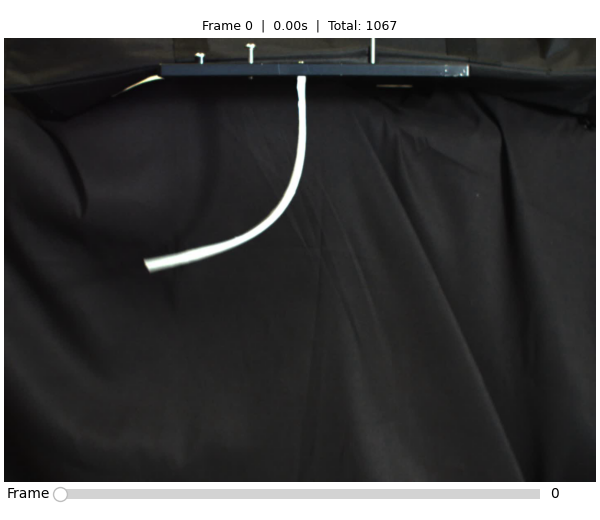

Use the slider to find the right frame range, then set FRAME_START / FRAME_END in the next cell.


In [209]:
%matplotlib widget
from matplotlib.widgets import Slider

_cap_preview, _tmp_preview = _open_video(VIDEO_PATH)
_total_preview = int(_cap_preview.get(cv2.CAP_PROP_FRAME_COUNT))
_fps_preview   = _cap_preview.get(cv2.CAP_PROP_FPS)
print(f'Total frames: {_total_preview}  |  FPS: {_fps_preview:.0f}  |  Duration: {_total_preview/_fps_preview:.1f}s')

def _get_frame(idx):
    _cap_preview.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = _cap_preview.read()
    if ret:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return np.zeros((100, 100, 3), dtype=np.uint8)

_first = _get_frame(0)
_h, _w = _first.shape[:2]
_scale = min(7.0 / _w, 4.5 / _h)

fig, _ax_vid = plt.subplots(figsize=(_w * _scale, _h * _scale + 0.7), dpi=100)
plt.subplots_adjust(bottom=0.12)
_img_disp = _ax_vid.imshow(_first)
_ax_vid.axis('off')
_title = _ax_vid.set_title(f'Frame 0  |  0.00s  |  Total: {_total_preview}', fontsize=9)

_ax_sl = fig.add_axes([0.1, 0.03, 0.8, 0.04])
_sl    = Slider(_ax_sl, 'Frame', 0, _total_preview - 1, valinit=0, valstep=1, color='steelblue')

def _on_slider(val):
    idx = int(_sl.val)
    _img_disp.set_data(_get_frame(idx))
    _title.set_text(f'Frame {idx}  |  {idx/_fps_preview:.2f}s  |  Total: {_total_preview}')
    fig.canvas.draw_idle()

_sl.on_changed(_on_slider)
plt.tight_layout(pad=0.3)
plt.show()
print('Use the slider to find the right frame range, then set FRAME_START / FRAME_END in the next cell.')

%matplotlib inline


In [210]:
# ── Set the frame range to process ───────────────────────────────────────────
# Edit these two values based on what you saw in the slider above,
# then re-run Step 1b so PIXELS_PER_METRE and CLAMP_PX are re-derived
# from frames inside this range.
FRAME_START = 0     # first frame to include (inclusive)
FRAME_END   = None    # last frame to include (exclusive); None = until end of video

# Apply defaults
if FRAME_END is None:
    FRAME_END = _total_preview

FRAME_START = max(0, FRAME_START)
FRAME_END   = min(_total_preview, FRAME_END)

print(f'Will process frames {FRAME_START} -> {FRAME_END}  ({FRAME_END - FRAME_START} frames)')
print(f'Time range: {FRAME_START/_fps_preview:.2f}s -> {FRAME_END/_fps_preview:.2f}s')
print()
print('If you changed FRAME_START or FRAME_END, re-run Step 1b to update calibration.')


Will process frames 0 -> 1067  (1067 frames)
Time range: 0.00s -> 5.50s

If you changed FRAME_START or FRAME_END, re-run Step 1b to update calibration.


In [211]:
# CLAMP_PX = [735.5, 25.4]

## Step 2b — Frame preview

Displays 4 sample frames to help verify , , and .
 is auto-detected in Step 1b — this preview lets you visually confirm the clamp location looks correct.

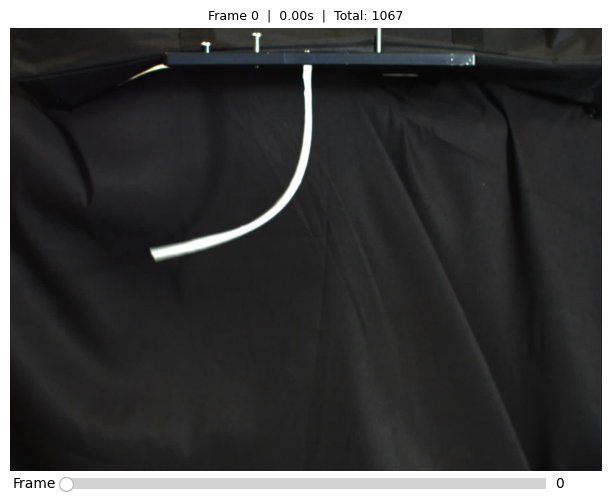

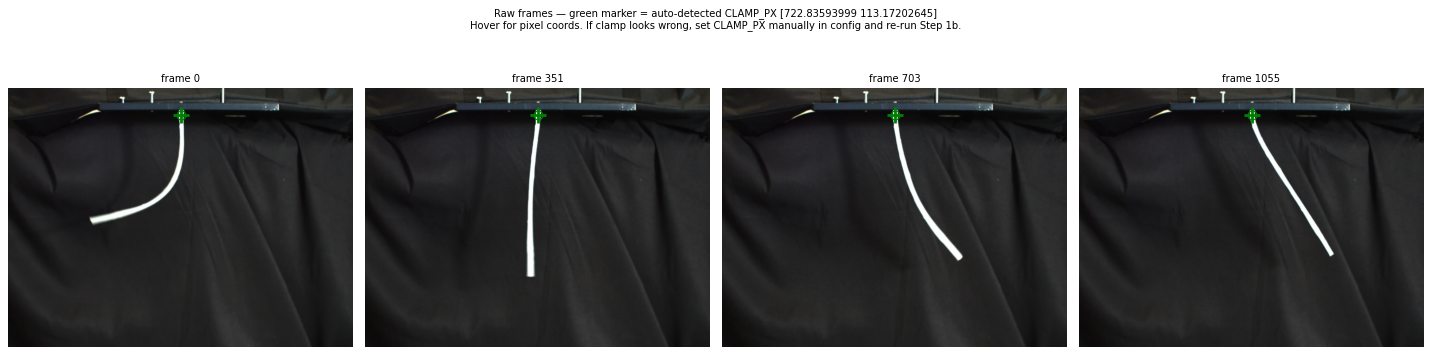

Clamp = fixed base attachment of the rod.


In [212]:
_cap, _tmp = _open_video(VIDEO_PATH)
_total     = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))

fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=80)
for _ax, _pct in zip(axes, [0.0, 0.33, 0.66, 0.99]):
    _idx = int(_pct * (_total - 1))
    _cap.set(cv2.CAP_PROP_POS_FRAMES, _idx)
    _ret, _fr = _cap.read()
    if not _ret:
        continue
    _ax.imshow(cv2.cvtColor(_fr, cv2.COLOR_BGR2RGB))
    if CLAMP_PX is not None:
        _ax.plot(CLAMP_PX[0], CLAMP_PX[1], 'g+', ms=14, mew=2.5, label='clamp')
        _ax.plot(CLAMP_PX[0], CLAMP_PX[1], 'go', ms=8, fillstyle='none')
    _ax.set_title(f'frame {_idx}', fontsize=9)
    _ax.axis('off')
_cap.release()
if _tmp: os.unlink(_tmp)
plt.suptitle(
    f'Raw frames — green marker = auto-detected CLAMP_PX {CLAMP_PX}\n'
    'Hover for pixel coords. If clamp looks wrong, set CLAMP_PX manually in config and re-run Step 1b.',
    fontsize=9)
plt.tight_layout()
plt.show()
print('Clamp = fixed base attachment of the rod.')


## Step 3 — Sub-pixel centreline functions

Core algorithm from `ros_centerline_3.py`, adapted for offline batch processing.

Key idea (from the game-dev staircase thread):
- Always scan along the **dominant axis** (the axis the rod spans more of).
- Along each scanline, find both rod edges via **sub-pixel quadratic interpolation**
  of the Sobel gradient peak.
- Centreline = midpoint of the two edges → **float coordinates**, not integer pixels.
- Fit cubic spline to float points → arc length is orientation-independent.

In [213]:
def _scan_axis(mask: np.ndarray, sobel_perp: np.ndarray, scan_rows: bool) -> list:
    """Scan along rows or columns; return list of (col_float, row_float) centreline pts.

    scan_rows=True  → step row by row, Sobel_x finds left/right edges
    scan_rows=False → step col by col, Sobel_y finds top/bottom edges

    For each scanline:
      1. Find the outermost ON-pixels (lo_px, hi_px) on the mask.
      2. Refine each edge position to sub-pixel via quadratic interpolation of
         the Sobel gradient peak (same idea as the game-dev velocity-slope trick:
         minor axis follows the gradient peak rather than being rounded).
      3. Midpoint = 0.5*(lo_px + hi_px) → float coordinate.
    """
    h, w = mask.shape
    pts = []
    n_lines = h if scan_rows else w

    for i in range(2, n_lines - 2):
        line_mask = mask[i, :] if scan_rows else mask[:, i]
        on = np.where(line_mask > 0)[0]
        if len(on) < 3:
            continue

        lo_px = float(on[0])
        hi_px = float(on[-1])
        grad_line = sobel_perp[i, :] if scan_rows else sobel_perp[:, i]

        # Sub-pixel low boundary (positive gradient peak)
        a0, a1 = max(0, int(lo_px) - 3), min(len(grad_line), int(lo_px) + 4)
        g = grad_line[a0:a1]
        if len(g) > 0 and g.max() > 0:
            pi = int(np.argmax(g))
            if 0 < pi < len(g) - 1:
                denom = g[pi-1] - 2*g[pi] + g[pi+1]
                if abs(denom) > 1e-6:
                    lo_px = a0 + pi - 0.5*(g[pi+1] - g[pi-1]) / denom

        # Sub-pixel high boundary (negative gradient peak)
        b0, b1 = max(0, int(hi_px) - 3), min(len(grad_line), int(hi_px) + 4)
        g = grad_line[b0:b1]
        if len(g) > 0 and g.min() < 0:
            pi = int(np.argmin(g))
            if 0 < pi < len(g) - 1:
                denom = g[pi-1] - 2*g[pi] + g[pi+1]
                if abs(denom) > 1e-6:
                    hi_px = b0 + pi - 0.5*(g[pi+1] - g[pi-1]) / denom

        mid = 0.5 * (lo_px + hi_px)
        pts.append((mid, float(i)) if scan_rows else (float(i), mid))  # (col, row)

    return pts


def _subpixel_centreline(
    mask: np.ndarray,
    clamp_rc=None,
    n_out: int = N_OUT,
    smooth_k: float = SPLINE_SMOOTH_K,
):
    """Extract sub-pixel centreline from binary rod mask.

    Returns (n_out, 2) float64 array [col, row] = [x, y], or None on failure.

    Steps:
      1. Measure bounding box → choose dominant scan axis.
      2. Compute Sobel along the perpendicular axis.
      3. _scan_axis → list of float (col, row) centreline points.
      4. Orient clamp→tip.
      5. Constrain tip to lie on the tangent from the last stable interior point
         (game-dev insight: minor axis follows slope, not rounded independently).
      6. Fit cubic spline, resample to n_out equidistant arc-length positions.
    """
    if mask is None or mask.sum() == 0:
        return None

    mask_f = mask.astype(np.float32) / 255.0

    rows_on = np.any(mask > 0, axis=1)
    cols_on = np.any(mask > 0, axis=0)
    n_rows_span = int(rows_on.sum())
    n_cols_span = int(cols_on.sum())
    scan_rows = (n_rows_span >= n_cols_span)

    if scan_rows:
        sobel_perp = cv2.Sobel(mask_f, cv2.CV_32F, 1, 0, ksize=3)
    else:
        sobel_perp = cv2.Sobel(mask_f, cv2.CV_32F, 0, 1, ksize=3)

    raw_pts = _scan_axis(mask, sobel_perp, scan_rows)
    if len(raw_pts) < MIN_SCANLINE_PTS:
        return None

    pts   = np.array(raw_pts, dtype=np.float64)  # (M, 2) [col, row]
    cols_c = pts[:, 0]
    rows_c = pts[:, 1]

    # Orient: clamp end first
    if clamp_rc is not None:
        cr, cc = clamp_rc
        if (rows_c[-1] - cr)**2 + (cols_c[-1] - cc)**2 < \
           (rows_c[0]  - cr)**2 + (cols_c[0]  - cc)**2:
            rows_c = rows_c[::-1]
            cols_c = cols_c[::-1]
        rows_c[0] = float(cr)
        cols_c[0] = float(cc)
    else:
        if rows_c[0] > rows_c[-1]:
            rows_c = rows_c[::-1]
            cols_c = cols_c[::-1]

    # Tip tangent constraint (game-dev insight applied to the free tip):
    # Instead of accepting whatever the last scanline gives as the tip,
    # extrapolate from the last N_TAN interior points along their mean tangent.
    # This prevents tip endpoint jumps from staircase aliasing.
    N_TAN = min(8, len(cols_c) // 4)
    if N_TAN >= 2:
        tan_cols = cols_c[-(N_TAN+1):-1]
        tan_rows = rows_c[-(N_TAN+1):-1]
        dc = tan_cols[-1] - tan_cols[0]
        dr = tan_rows[-1] - tan_rows[0]
        tang_len = np.sqrt(dc**2 + dr**2)
        if tang_len > 1.0:
            # Project the last raw point onto the tangent line from tan_cols[-1]
            tx, ty = dc / tang_len, dr / tang_len
            dx = cols_c[-1] - tan_cols[-1]
            dy = rows_c[-1] - tan_rows[-1]
            proj = dx*tx + dy*ty
            cols_c[-1] = tan_cols[-1] + proj * tx
            rows_c[-1] = tan_rows[-1] + proj * ty

    # Remove duplicate consecutive points
    diffs = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
    keep  = np.concatenate([[True], diffs > 0.1])
    cols_c, rows_c = cols_c[keep], rows_c[keep]
    if len(cols_c) < 4:
        return None

    # Arc-length parameterised cubic spline
    seg = np.sqrt(np.diff(cols_c)**2 + np.diff(rows_c)**2)
    arc = np.concatenate([[0.0], np.cumsum(seg)])
    if arc[-1] < 5.0:
        return None

    try:
        tck, _ = splprep([cols_c, rows_c], u=arc, s=smooth_k * len(cols_c), k=3)
    except Exception:
        return None

    t_out = np.linspace(0.0, arc[-1], n_out)
    c_s, r_s = splev(t_out, tck)
    return np.stack([c_s, r_s], axis=1)  # float64 [col, row]


def process_frame(frame_bgr, roi, thresh_val, invert, clamp_px):
    """Full per-frame pipeline. Returns (line_pts_xy_float, debug_mask) or (None, None).

    line_pts_xy_float: (N_OUT, 2) float64 [x=col, y=row] in full-frame pixel coords.
    """
    if roi is not None:
        x1, y1, x2, y2 = roi
        region = frame_bgr[y1:y2, x1:x2]
        ox, oy = x1, y1
    else:
        region = frame_bgr
        ox, oy = 0, 0

    gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
    ttype = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, mask = cv2.threshold(gray, thresh_val, 255, ttype)

    # Keep largest connected component
    n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_lab < 2:
        return None, None
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    clean_mask = np.zeros_like(mask)
    clean_mask[labels == largest] = 255

    # Morphological cleaning
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_CLOSE_K, MORPH_CLOSE_K))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_OPEN_K,  MORPH_OPEN_K))
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, k_close, iterations=1)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN,  k_open,  iterations=1)

    clamp_rc = None
    if clamp_px is not None:
        clamp_rc = (clamp_px[1] - oy, clamp_px[0] - ox)  # (row, col) in ROI coords

    line_pts = _subpixel_centreline(clean_mask, clamp_rc=clamp_rc)
    if line_pts is None:
        return None, clean_mask

    # Shift back to full-frame coords
    line_pts[:, 0] += ox
    line_pts[:, 1] += oy

    return line_pts, clean_mask


print('Sub-pixel centreline functions defined.')

Sub-pixel centreline functions defined.


## Step 3b — Threshold preview

Check that the threshold cleanly isolates the rod on 4 sample frames.
Adjust `THRESH_VAL` and `INVERT_THRESH` in the config cell if needed.

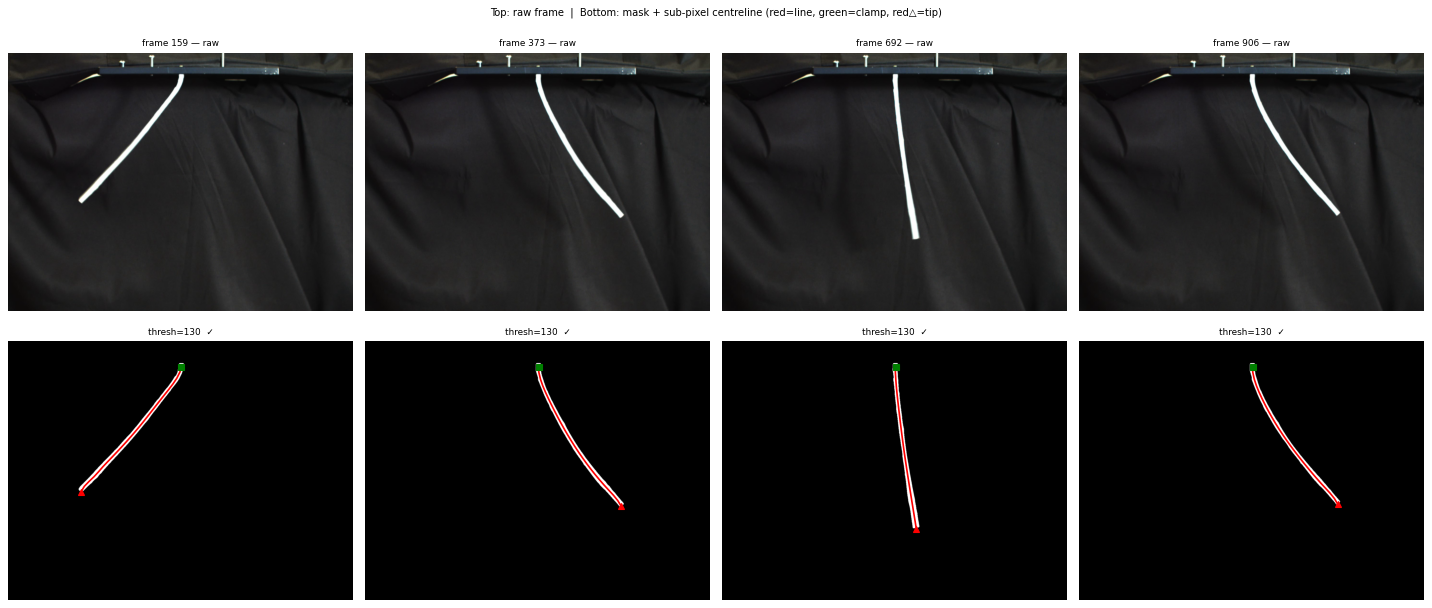

In [214]:
_cap, _tmp = _open_video(VIDEO_PATH)
_total     = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))

fig, axes = plt.subplots(2, 4, figsize=(18, 8), dpi=80)
for _col, _pct in enumerate([0.15, 0.35, 0.65, 0.85]):
    _idx = int(_pct * (_total - 1))
    _cap.set(cv2.CAP_PROP_POS_FRAMES, _idx)
    _, _fr = _cap.read()
    if _fr is None: continue
    _roi = ROI
    _reg = _fr[_roi[1]:_roi[3], _roi[0]:_roi[2]] if _roi else _fr
    _gray = cv2.cvtColor(_reg, cv2.COLOR_BGR2GRAY)
    _tt = cv2.THRESH_BINARY_INV if INVERT_THRESH else cv2.THRESH_BINARY
    _, _mask = cv2.threshold(_gray, THRESH_VAL, 255, _tt)
    _n, _labels, _stats, _ = cv2.connectedComponentsWithStats(_mask, 8)
    _clean = np.zeros_like(_mask)
    if _n >= 2:
        _lg = 1 + int(np.argmax(_stats[1:, cv2.CC_STAT_AREA]))
        _clean[_labels == _lg] = 255

    # Also run sub-pixel detection
    _lp, _ = process_frame(_fr, _roi, THRESH_VAL, INVERT_THRESH, CLAMP_PX)

    axes[0, _col].imshow(cv2.cvtColor(_reg, cv2.COLOR_BGR2RGB))
    axes[0, _col].set_title(f'frame {_idx} — raw', fontsize=8)
    axes[0, _col].axis('off')

    axes[1, _col].imshow(_clean, cmap='gray')
    if _lp is not None:
        _ox = _roi[0] if _roi else 0
        _oy = _roi[1] if _roi else 0
        axes[1, _col].plot(_lp[:, 0] - _ox, _lp[:, 1] - _oy, 'r-', lw=1.5)
        axes[1, _col].plot(_lp[0, 0]-_ox, _lp[0, 1]-_oy, 'gs', ms=6)
        axes[1, _col].plot(_lp[-1,0]-_ox, _lp[-1,1]-_oy, 'r^', ms=6)
    axes[1, _col].set_title(f'thresh={THRESH_VAL}  {"✓" if _lp is not None else "✗ failed"}', fontsize=8)
    axes[1, _col].axis('off')

_cap.release()
if _tmp: os.unlink(_tmp)
plt.suptitle('Top: raw frame  |  Bottom: mask + sub-pixel centreline (red=line, green=clamp, red△=tip)', fontsize=9)
plt.tight_layout()
plt.show()

## Step 4 — Main processing loop

Processes every frame in `[FRAME_START, FRAME_END)` and collects:
- `all_pts_px` — raw sub-pixel centreline in full-frame pixel coords
- `arc_px` — arc length (pixels) per frame for diagnostics

In [215]:
_cap, _tmp = _open_video(VIDEO_PATH)
_total = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_end   = FRAME_END if FRAME_END is not None else _total
frame_end   = min(frame_end, _total)
frame_start = max(0, FRAME_START)
n_frames    = frame_end - frame_start
print(f'Processing frames {frame_start}→{frame_end}  ({n_frames} frames)  {_total} total')

_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)

all_pts_px  = []   # list of (N_OUT, 2) float64 [col, row] per accepted frame
frame_idxs  = []   # original frame indices
arc_px      = []   # arc length in pixels per frame
skipped     = []   # (frame_idx, reason)

for _fi in range(frame_start, frame_end):
    _ret, _fr = _cap.read()
    if not _ret:
        break

    _lp, _ = process_frame(_fr, ROI, THRESH_VAL, INVERT_THRESH, CLAMP_PX)

    if _lp is None:
        skipped.append((_fi, 'detection_failed'))
        continue

    # Clamp endpoint filter
    _d_clamp = np.sqrt((_lp[0,0]-CLAMP_PX[0])**2 + (_lp[0,1]-CLAMP_PX[1])**2)
    if _d_clamp > MAX_CLAMP_DIST_PX:
        skipped.append((_fi, f'clamp_dist={_d_clamp:.1f}px'))
        continue

    _seg = np.diff(_lp, axis=0)
    _arc = float(np.sum(np.sqrt((_seg**2).sum(axis=1))))
    arc_px.append(_arc)
    all_pts_px.append(_lp.copy())
    frame_idxs.append(_fi)

    if (_fi - frame_start + 1) % 100 == 0:
        print(f'  frame {_fi}/{frame_end}  kept={len(all_pts_px)}  skipped={len(skipped)}')

_cap.release()
if _tmp: os.unlink(_tmp)

print(f'\nDone. Kept {len(all_pts_px)}/{n_frames} frames  ({len(skipped)} skipped)')
if skipped[:10]:
    print('First skipped frames:')
    for _fi, _r in skipped[:10]:
        print(f'  frame {_fi}: {_r}')

Processing frames 0→1067  (1067 frames)  1067 total
  frame 99/1067  kept=100  skipped=0
  frame 199/1067  kept=200  skipped=0
  frame 299/1067  kept=300  skipped=0
  frame 399/1067  kept=400  skipped=0
  frame 499/1067  kept=500  skipped=0
  frame 599/1067  kept=600  skipped=0
  frame 699/1067  kept=700  skipped=0
  frame 799/1067  kept=800  skipped=0
  frame 899/1067  kept=900  skipped=0
  frame 999/1067  kept=1000  skipped=0

Done. Kept 1067/1067 frames  (0 skipped)


## Step 4b — Tip temporal smoothing

Applies a median filter over time to the last `N_TIP_NODES` nodes of every frame.
The rod body is stable; only the free tip bounces due to mask fraying at the endpoint.
A small window (default ±4 frames = 9-frame median) kills tip jumps without affecting interior nodes.

Re-run Steps 5, 5b, and 6+ after changing `N_TIP_NODES` or `TIP_SMOOTH_HALF`.


In [216]:
from scipy.signal import medfilt

N_TIP_NODES      = 2   # how many nodes from the tip to smooth
TIP_SMOOTH_HALF  = 4   # half-window in frames; full window = 2*half+1

win = 2 * TIP_SMOOTH_HALF + 1

# all_pts_px is a list of (N_OUT, 2) arrays — convert to a 3D array for easy filtering
pts_arr = np.stack(all_pts_px, axis=0)   # (n_frames, N_OUT, 2)

before_tip = pts_arr[:, -N_TIP_NODES:, :].copy()

for node_idx in range(N_OUT - N_TIP_NODES, N_OUT):
    for coord in range(2):   # 0=col, 1=row
        pts_arr[:, node_idx, coord] = medfilt(pts_arr[:, node_idx, coord], kernel_size=win)

# Write back to list
all_pts_px = [pts_arr[i] for i in range(len(all_pts_px))]

# Recompute arc lengths with smoothed tip
arc_px = []
for pts in all_pts_px:
    seg = np.diff(pts, axis=0)
    arc_px.append(float(np.sqrt((seg**2).sum(axis=1)).sum()))

# Report tip jump improvement
tips_before = before_tip                          # (n, N_TIP_NODES, 2)
tips_after  = pts_arr[:, -N_TIP_NODES:, :]       # (n, N_TIP_NODES, 2)

jump_before = np.sqrt(np.sum(np.diff(tips_before[:, -1, :], axis=0)**2, axis=1))
jump_after  = np.sqrt(np.sum(np.diff(tips_after[:, -1, :],  axis=0)**2, axis=1))

print(f'Tip smoothing: window={win} frames ({win/FPS*1000:.1f} ms)  nodes smoothed: last {N_TIP_NODES}')
print(f'  Tip jump before: mean={jump_before.mean():.2f} px  std={jump_before.std():.2f} px  max={jump_before.max():.2f} px')
print(f'  Tip jump after:  mean={jump_after.mean():.2f} px  std={jump_after.std():.2f} px  max={jump_after.max():.2f} px')

arc_arr_smooth = np.array(arc_px) / PIXELS_PER_METRE
print(f'  Arc std after smoothing: {arc_arr_smooth.std()*1000:.2f} mm  (was {np.array(arc_px).std()/PIXELS_PER_METRE*1000:.2f} mm before this cell)')

all_pts_px_raw = [p.copy() for p in all_pts_px]


Tip smoothing: window=9 frames (46.4 ms)  nodes smoothed: last 2
  Tip jump before: mean=11.67 px  std=8.53 px  max=64.54 px
  Tip jump after:  mean=11.51 px  std=8.40 px  max=36.42 px
  Arc std after smoothing: 2.58 mm  (was 2.58 mm before this cell)


## Step 4c — Motion-adaptive EMA smoothing

Ported from `ros_centerline_3.py` (lines 604-615). Applies a forward + backward
EMA pass across frames to smooth tip curls before spline fitting.
Forward-only EMA is used in the live ROS pipeline (no future frames available);
the backward pass here makes the filter zero-phase (no temporal lag).

- `ALPHA_MIN`: smoothing weight when rod is stationary (heavy smoothing)
- `ALPHA_MAX`: smoothing weight when rod moves fast (follows motion)
- `MOTION_THRESH`: mean node displacement (px) that triggers full `ALPHA_MAX`

Re-run Steps 5, 5b, and 6+ after changing these parameters.

In [ ]:
ALPHA_MIN     = 0.05
ALPHA_MAX     = 0.5
MOTION_THRESH = 5.0   # pixels: mean node displacement triggering full alpha_max

pts_arr = np.stack(all_pts_px, axis=0).astype(np.float64)  # (n_frames, N_OUT, 2)
n_f = pts_arr.shape[0]

# Forward pass
ema = pts_arr[0].copy()
pts_ema = np.zeros_like(pts_arr)
pts_ema[0] = ema
for fi in range(1, n_f):
    motion = float(np.mean(np.sqrt(np.sum((pts_arr[fi] - ema)**2, axis=1))))
    t      = min(1.0, motion / MOTION_THRESH)
    alpha  = ALPHA_MIN + t * (ALPHA_MAX - ALPHA_MIN)
    ema    = alpha * pts_arr[fi] + (1.0 - alpha) * ema
    pts_ema[fi] = ema

# Backward pass (zero-phase: removes temporal lag from forward pass)
ema = pts_ema[-1].copy()
for fi in range(n_f - 2, -1, -1):
    motion = float(np.mean(np.sqrt(np.sum((pts_ema[fi] - ema)**2, axis=1))))
    t      = min(1.0, motion / MOTION_THRESH)
    alpha  = ALPHA_MIN + t * (ALPHA_MAX - ALPHA_MIN)
    ema    = alpha * pts_ema[fi] + (1.0 - alpha) * ema
    pts_ema[fi] = ema

# Write back to all_pts_px
all_pts_px = [pts_ema[fi] for fi in range(n_f)]
print(f"EMA smoothing done. alpha=[{ALPHA_MIN}, {ALPHA_MAX}], MOTION_THRESH={MOTION_THRESH} px, frames={n_f}")


## Step 5 — Arc-length diagnostics

This is the key quality check. A good sub-pixel result should show:
- Arc length std << 10 px (compare with skeletonization which has ~11–79 px range)
- No systematic drift correlated with rod angle
- Tip jump (frame-to-frame displacement of tip point) < 5 px most of the time

=== Arc-length statistics (sub-pixel pipeline) ===
  mean  = 27.55 cm  (expected ~28.0 cm)
  std   = 2.58 mm
  range = 18.82 mm
  min   = 26.208 cm   max = 28.090 cm

  Tip jump (px): mean=11.51  std=8.40  max=36.42


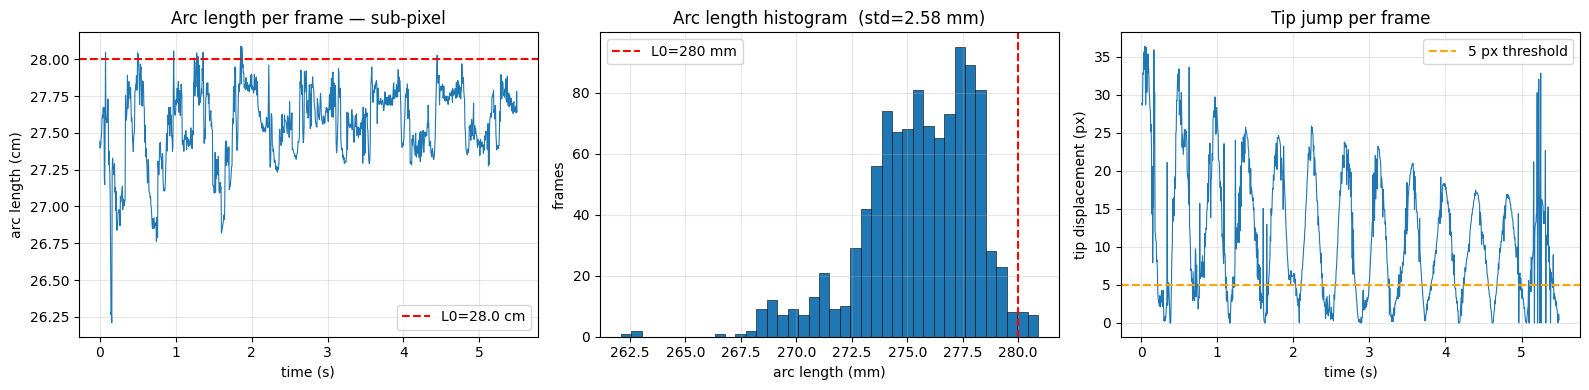

Saved arc CSV: Processed_data/arc_length_per_frame.csv


In [217]:
arc_arr  = np.array(arc_px)          # pixels
arc_m    = arc_arr / PIXELS_PER_METRE  # metres
t_frames = np.array(frame_idxs, dtype=float) / FPS

# Tip jump: frame-to-frame displacement of the last point
tips  = np.array([p[-1] for p in all_pts_px])   # (n, 2)
tip_jump = np.sqrt(np.sum(np.diff(tips, axis=0)**2, axis=1))

print('=== Arc-length statistics (sub-pixel pipeline) ===')
print(f'  mean  = {arc_m.mean()*100:.2f} cm  (expected ~{L0*100:.1f} cm)')
print(f'  std   = {arc_m.std()*1000:.2f} mm')
print(f'  range = {(arc_m.max()-arc_m.min())*1000:.2f} mm')
print(f'  min   = {arc_m.min()*100:.3f} cm   max = {arc_m.max()*100:.3f} cm')
print(f'\n  Tip jump (px): mean={tip_jump.mean():.2f}  std={tip_jump.std():.2f}  max={tip_jump.max():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=100)

axes[0].plot(t_frames, arc_m * 100, lw=0.8)
axes[0].axhline(L0 * 100, color='r', ls='--', label=f'L0={L0*100:.1f} cm')
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('arc length (cm)')
axes[0].set_title('Arc length per frame — sub-pixel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(arc_m * 1000, bins=40, edgecolor='k', linewidth=0.4)
axes[1].axvline(L0 * 1000, color='r', ls='--', label=f'L0={L0*1000:.0f} mm')
axes[1].set_xlabel('arc length (mm)')
axes[1].set_ylabel('frames')
axes[1].set_title(f'Arc length histogram  (std={arc_m.std()*1000:.2f} mm)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_frames[1:], tip_jump, lw=0.8)
axes[2].axhline(5, color='orange', ls='--', label='5 px threshold')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('tip displacement (px)')
axes[2].set_title('Tip jump per frame')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save CSV for external analysis
np.savetxt(OUT_ARC_CSV,
           np.column_stack([frame_idxs, t_frames, arc_m]),
           header='frame_idx  time_s  arc_m', fmt='%d %.6f %.8f')
print(f'Saved arc CSV: {OUT_ARC_CSV}')

## Step 5a — Arc-length normalisation

Rescales each frame so the total 2D polygonal arc = `L0` exactly.

**Why:** GPR models were trained on synthetic planar data with `arc = L0` always. Real data has arc ≈ 27.73 cm due to out-of-plane projection. Normalising puts `dxds`, `dyds`, `θ` back in the training distribution.

**What it does:** Rebuilds each frame from the clamped base by scaling every segment vector by `L0 / arc_measured`. Clamp position is preserved.

Arc after normalisation:  mean=28.0000 cm  std=0.0000 mm  max_err=0.00 um


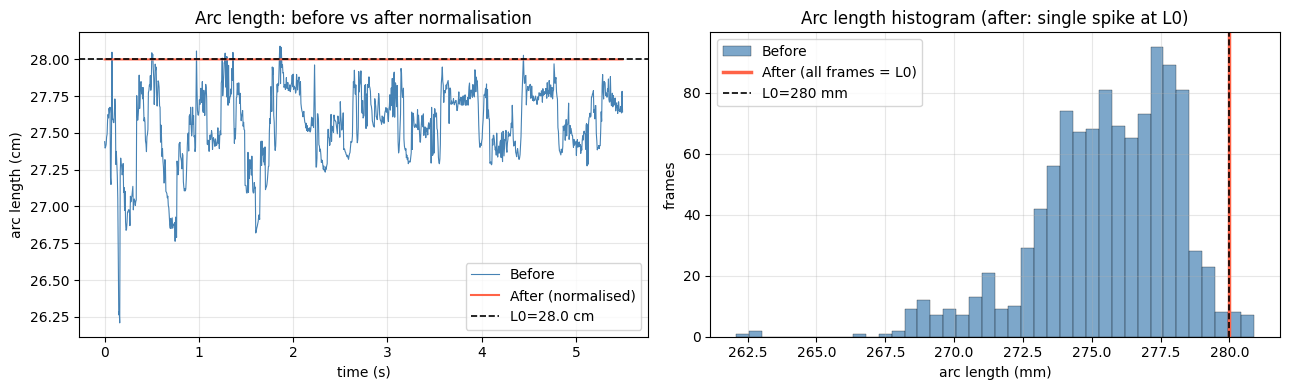

In [218]:
# ── Step 5a: Arc-length normalisation ────────────────────────────────
# Rescale each frame so the 2D polygonal arc = L0 exactly.
# Works on all_pts_px in pixel coordinates.

all_pts_px_norm = []
arc_norm_m = np.zeros(len(all_pts_px))

for fi, pts in enumerate(all_pts_px):
    segs = np.diff(pts, axis=0)              # (N, 2) segment vectors in px
    seg_lens = np.linalg.norm(segs, axis=1)  # (N,) lengths in px
    arc_px_frame = seg_lens.sum()

    scale = (L0 * PIXELS_PER_METRE) / arc_px_frame
    segs_norm = segs * scale

    pts_norm = np.zeros_like(pts)
    pts_norm[0] = pts[0]                     # clamp fixed
    for k in range(len(segs_norm)):
        pts_norm[k+1] = pts_norm[k] + segs_norm[k]

    all_pts_px_norm.append(pts_norm)
    arc_norm_m[fi] = np.linalg.norm(np.diff(pts_norm, axis=0), axis=1).sum() / PIXELS_PER_METRE

# Overwrite all_pts_px with normalised version
all_pts_px = all_pts_px_norm

max_err_um = float(np.abs(arc_norm_m - L0).max() * 1e6)
print(f'Arc after normalisation:  mean={arc_norm_m.mean()*100:.4f} cm  '
      f'std={arc_norm_m.std()*1000:.4f} mm  max_err={max_err_um:.2f} um')

# ── Plot: before vs after normalisation ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=100)

# Left: time series
axes[0].plot(t_frames, arc_m * 100, lw=0.8, color='steelblue', label='Before')
axes[0].plot(t_frames, arc_norm_m * 100, lw=1.5, color='tomato', label='After (normalised)')
axes[0].axhline(L0 * 100, color='k', ls='--', lw=1.2, label=f'L0={L0*100:.1f} cm')
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('arc length (cm)')
axes[0].set_title('Arc length: before vs after normalisation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: histogram of 'before' only; after is a single vertical line at L0
axes[1].hist(arc_m * 1000, bins=40, alpha=0.7, color='steelblue', label='Before', edgecolor='k', linewidth=0.3)
axes[1].axvline(L0 * 1000, color='tomato', ls='-', lw=2.5, label='After (all frames = L0)')
axes[1].axvline(L0 * 1000, color='k', ls='--', lw=1.2, label=f'L0={L0*1000:.0f} mm')
axes[1].set_xlabel('arc length (mm)')
axes[1].set_ylabel('frames')
axes[1].set_title('Arc length histogram (after: single spike at L0)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 5b — Centreline overlay on raw video

Shows the sub-pixel centreline drawn on the actual raw video frames (not the mask).

- Green square = clamp (node 0)
- Red triangle = tip (last node)
- Red line = full centreline


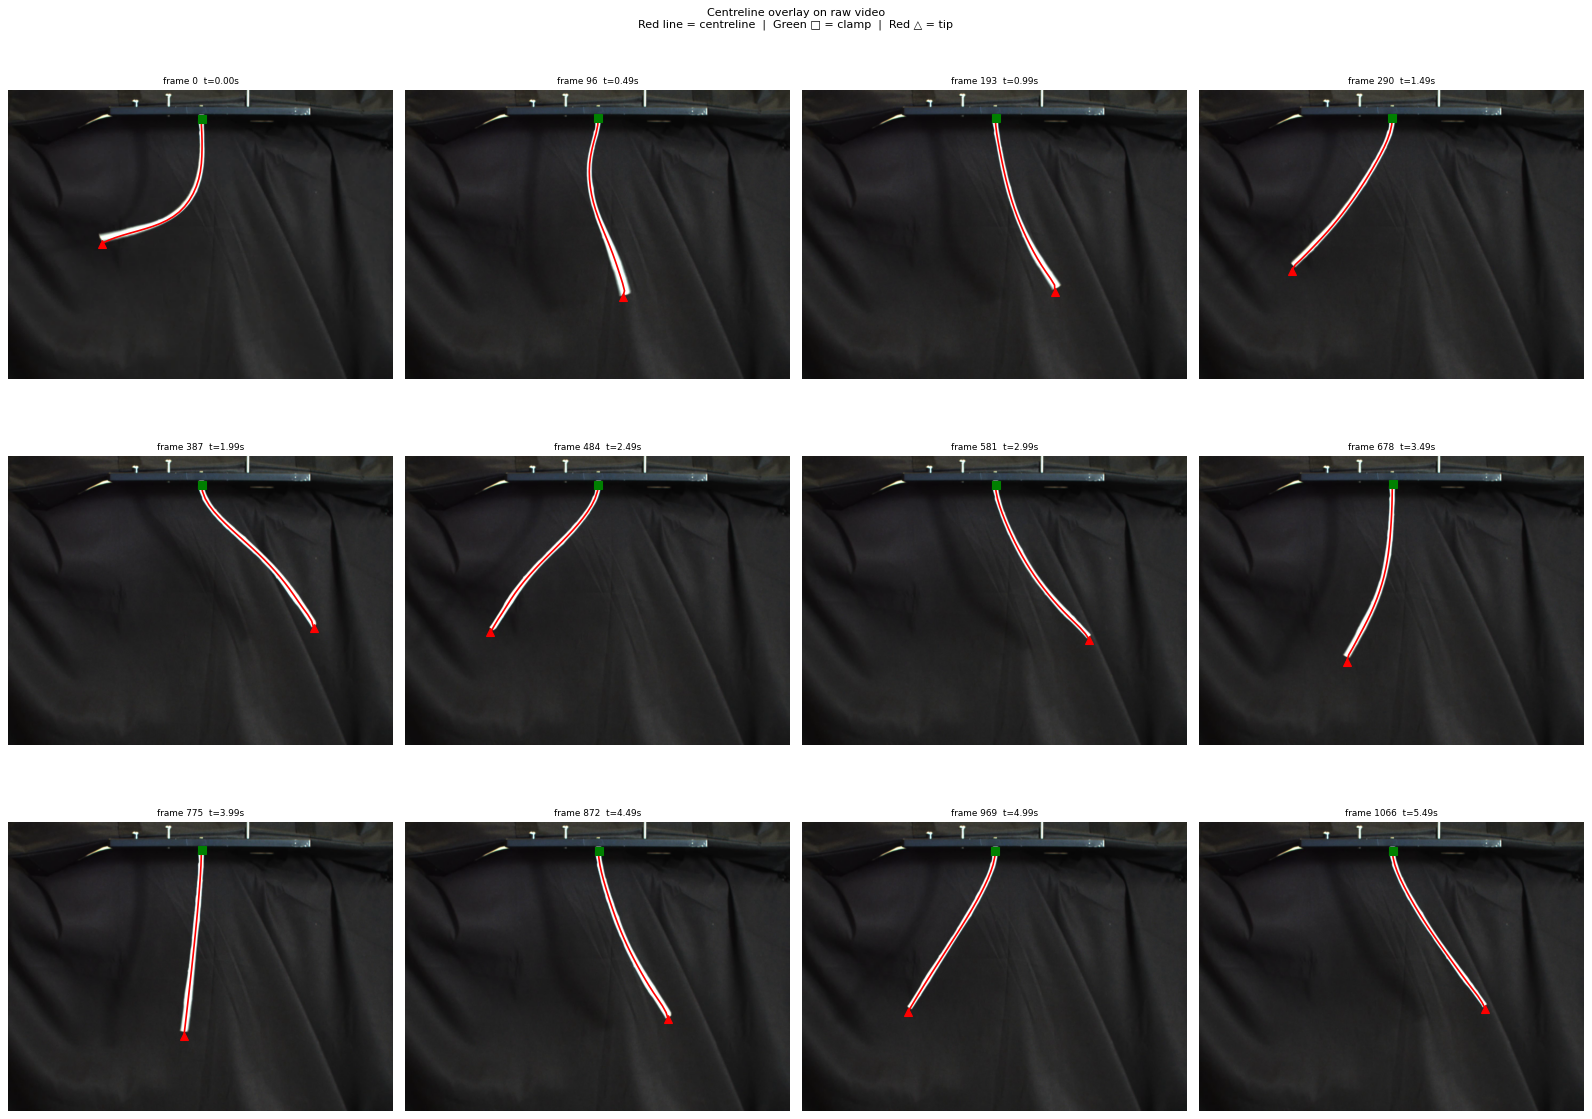

In [219]:
# Run after Step 3 and Step 4.
# Shows N_PREVIEW evenly-spaced frames from all_pts_px drawn on the raw video.

N_PREVIEW = 12   # number of frames to display

_cap, _tmp = _open_video(VIDEO_PATH)

_indices = np.linspace(0, len(all_pts_px) - 1, N_PREVIEW, dtype=int)
_n_cols  = 4
_n_rows  = int(np.ceil(N_PREVIEW / _n_cols))

fig, axes = plt.subplots(_n_rows, _n_cols, figsize=(20, _n_rows * 5), dpi=80)
axes = axes.flatten()

for _k, _ki in enumerate(_indices):
    _fi   = frame_idxs[_ki]
    _pts  = all_pts_px[_ki]          # (N_OUT, 2) [col, row] in full-frame px

    _cap.set(cv2.CAP_PROP_POS_FRAMES, _fi)
    _ret, _fr = _cap.read()
    _ax = axes[_k]
    if not _ret:
        _ax.set_visible(False)
        continue

    _ax.imshow(cv2.cvtColor(_fr, cv2.COLOR_BGR2RGB))
    _ax.plot(_pts[:, 0], _pts[:, 1], 'r-',  lw=1.5)
    _ax.plot(_pts[0, 0], _pts[0, 1], 'gs',  ms=7)   # clamp
    _ax.plot(_pts[-1,0], _pts[-1,1], 'r^',  ms=7)   # tip
    _ax.set_title(f'frame {_fi}  t={_fi/FPS:.2f}s', fontsize=8)
    _ax.axis('off')

for _k in range(len(_indices), len(axes)):
    axes[_k].set_visible(False)

_cap.release()
if _tmp: os.unlink(_tmp)

plt.suptitle(
    'Centreline overlay on raw video\n'
    'Red line = centreline  |  Green □ = clamp  |  Red △ = tip',
    fontsize=10)
plt.tight_layout()
plt.show()


### Raw tip trajectory before GP smoothing

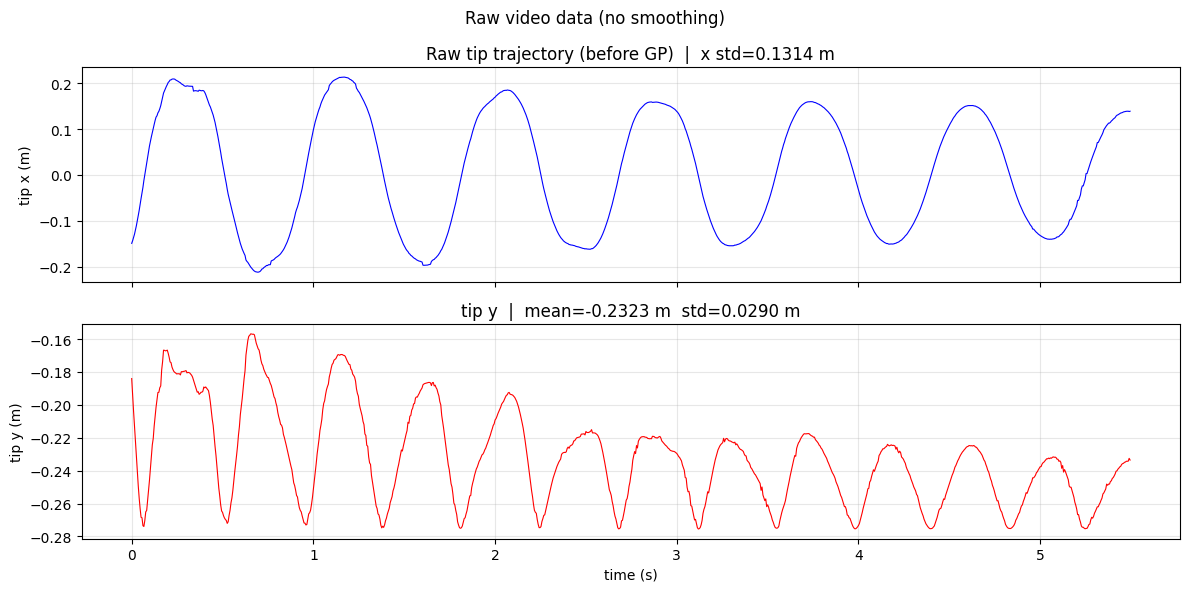

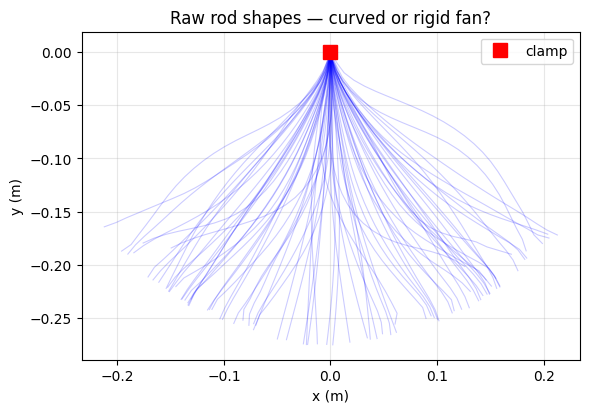

In [220]:
# Recompute raw tip positions from all_pts_px (before GP overwrote x_m)
n_raw = len(all_pts_px)
_clamp_col, _clamp_row = float(CLAMP_PX[0]), float(CLAMP_PX[1])
tip_x_raw = np.array([( p[-1, 0] - _clamp_col) / PIXELS_PER_METRE for p in all_pts_px])
tip_y_raw = np.array([-( p[-1, 1] - _clamp_row) / PIXELS_PER_METRE for p in all_pts_px])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=100, sharex=True)
axes[0].plot(t_frames, tip_x_raw, 'b-', lw=0.8)
axes[0].set_ylabel('tip x (m)'); axes[0].grid(True, alpha=0.3)
axes[0].set_title(f'Raw tip trajectory (before GP)  |  x std={tip_x_raw.std():.4f} m')

axes[1].plot(t_frames, tip_y_raw, 'r-', lw=0.8)
axes[1].set_ylabel('tip y (m)'); axes[1].grid(True, alpha=0.3)
axes[1].set_title(f'tip y  |  mean={tip_y_raw.mean():.4f} m  std={tip_y_raw.std():.4f} m')
axes[1].set_xlabel('time (s)')
plt.suptitle('Raw video data (no smoothing)')
plt.tight_layout(); plt.show()

# Rod shapes
x_m_raw = np.zeros((n_raw, N_OUT))
y_m_raw = np.zeros((n_raw, N_OUT))
for _i, _lp in enumerate(all_pts_px):
    x_m_raw[_i] = ( _lp[:, 0] - _clamp_col) / PIXELS_PER_METRE
    y_m_raw[_i] = -(_lp[:, 1] - _clamp_row) / PIXELS_PER_METRE

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)
for _i in np.linspace(0, n_raw-1, 80, dtype=int):
    ax.plot(x_m_raw[_i], y_m_raw[_i], 'b-', alpha=0.2, lw=0.8)
ax.plot(0, 0, 'rs', ms=10, label='clamp')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Raw rod shapes — curved or rigid fan?')
ax.legend(); plt.tight_layout(); plt.show()


## Step 6 — Convert to physical coordinates

Pixel → metres, flip y (image y increases downward, physical y upward),
anchor clamp to (0, 0).

Physical arc length: mean=28.21 cm  std=1.31 mm
  (expected ~28.0 cm)


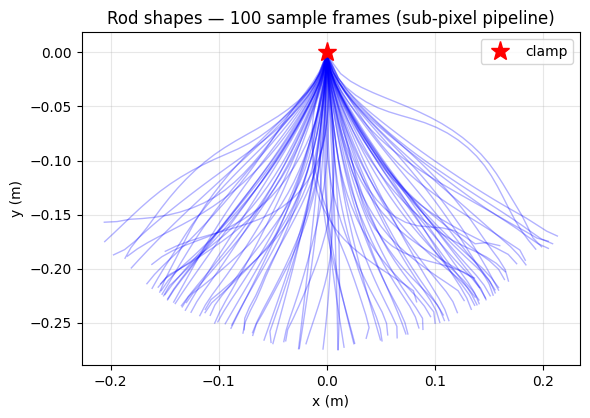

In [221]:
n_kept   = len(all_pts_px)
t_kept   = np.array(frame_idxs, dtype=float) / FPS
t_kept   = t_kept - t_kept[0]
t_kept_orig = t_kept.copy()   # original camera timestamps — never overwritten by TARGET_FPS

n_nodes  = N_OUT  # same as N+1 from MATLAB — we output N_OUT=25 points = N=24 segments
          # NOTE: if you need N+1=26 nodes (N=25 segs), change N_OUT in config to 26

# Convert pixel [col, row] → physical [x_m, y_m]
#   col → x  (rightward)    : x =  (col - clamp_col) / ppm
#   row → y  (upward)       : y = -(row - clamp_row) / ppm   (flip)
clamp_col, clamp_row = float(CLAMP_PX[0]), float(CLAMP_PX[1])

x_m = np.zeros((n_kept, n_nodes))   # (frames, N_OUT)
y_m = np.zeros((n_kept, n_nodes))

for _i, _lp in enumerate(all_pts_px):
    x_m[_i] = ( _lp[:, 0] - clamp_col) / PIXELS_PER_METRE
    y_m[_i] = -(_lp[:, 1] - clamp_row) / PIXELS_PER_METRE

# Enforce clamp at (0, 0)
x_m[:, 0] = 0.0
y_m[:, 0] = 0.0

# Arc-length in metres (cross-check)
arc_m2 = np.sqrt(np.diff(x_m, axis=1)**2 + np.diff(y_m, axis=1)**2).sum(axis=1)
print(f'Physical arc length: mean={arc_m2.mean()*100:.2f} cm  std={arc_m2.std()*1000:.2f} mm')
print(f'  (expected ~{L0*100:.1f} cm)')

# Plot n sample shapes
n = 100
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
for _i in np.linspace(0, n_kept-1, n, dtype=int):
    ax.plot(x_m[_i], y_m[_i], 'b', alpha=0.3, lw=1)
ax.plot(0, 0, 'r*', ms=14, label='clamp')
ax.set_aspect('equal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title(f'Rod shapes — {n} sample frames (sub-pixel pipeline)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6b — Temporal GP smoothing per node

Fits a Matérn-5/2 + WhiteKernel GP to `t → x(t)` and `t → y(t)` for each of
the N+1 nodes, and `t → θ(t)` for each of the N segments.

- Replaces the raw `np.gradient` on noisy pixel positions
- Velocities `ẋ`, `ẏ`, `θ̇` are computed via `np.gradient` on the GP mean
  (smooth curve → no ±600 rad/s spikes)
- Node 0 (clamp) is forced to zero throughout — not fitted

This is the same approach as `real_data_reconstruction.ipynb` Steps 4d–4e.
At 194 Hz the GP acts as a temporal smoother only (no upsampling needed).


Original FPS: 194.00  → resampling to TARGET_FPS=194.0
theta_raw range: [-3.159, 7.880] rad  (-181.0° to 451.5°)
Fitting temporal GPs: 25 x-GPs, 25 y-GPs, 25 θ-GPs  (1067 frames) ...
  x/y GP: node 5/25 done
  x/y GP: node 10/25 done
  x/y GP: node 15/25 done
  x/y GP: node 20/25 done
  x/y GP: node 25/25 done
  θ  GP: seg  0/24 done
  θ  GP: seg  5/24 done
  θ  GP: seg  10/24 done
  θ  GP: seg  15/24 done
  θ  GP: seg  20/24 done
All GPs fitted.

After GP smoothing:
  xdot   range: [-2.302, 2.645] m/s
  ydot   range: [-1.866, 1.328] m/s
  θdot   range: [-37.978, 41.585] rad/s


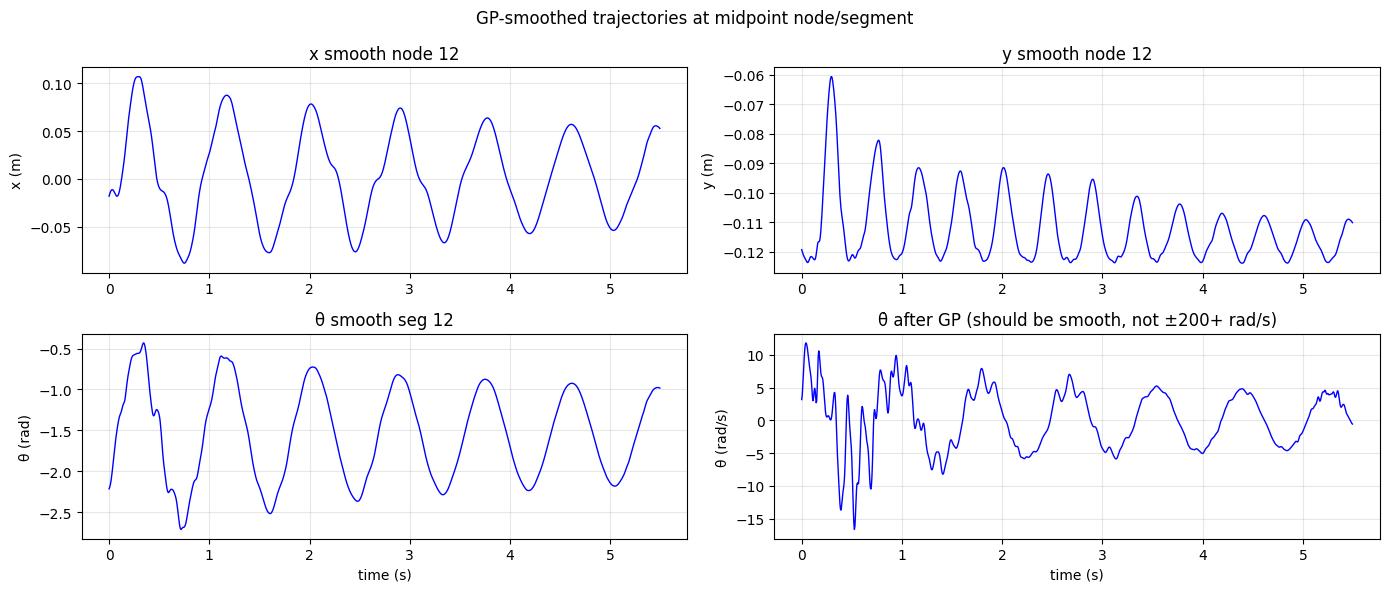

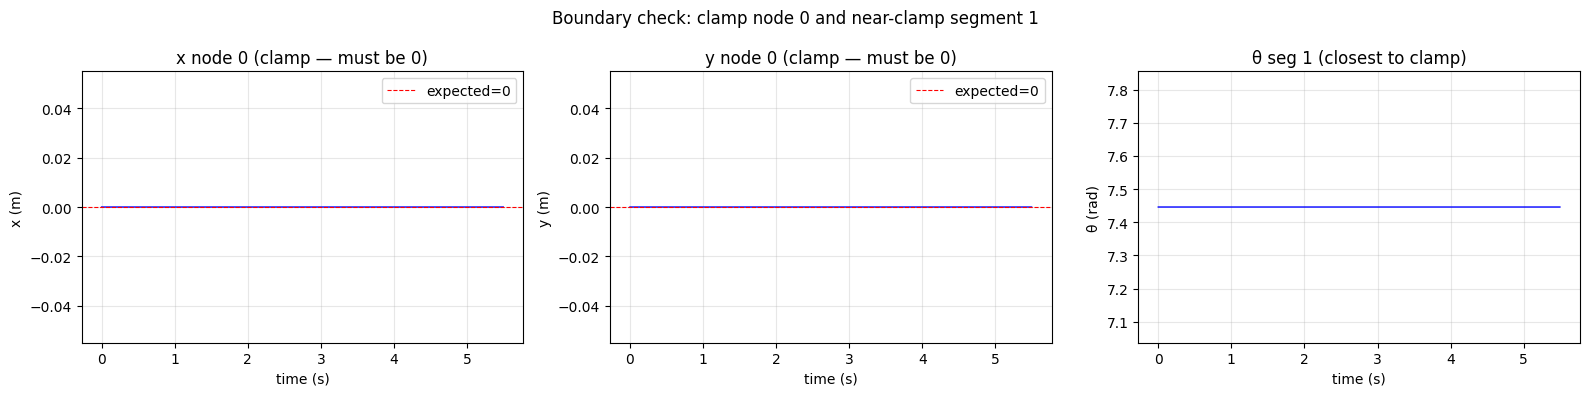

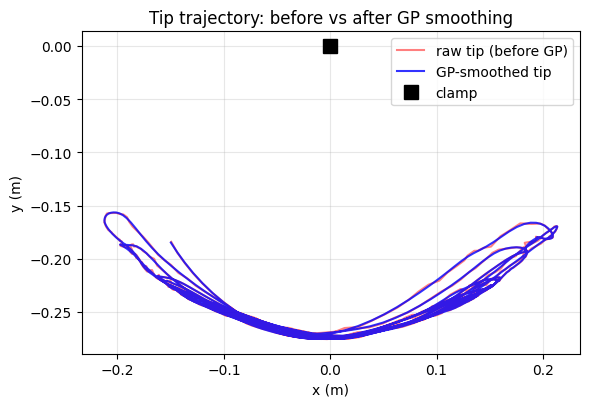

In [ ]:
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor as _GPR
from sklearn.gaussian_process.kernels import Matern as _Matern, WhiteKernel as _WK

TARGET_FPS = FPS   # set to e.g. 300 to upsample; None = keep original FPS
if TARGET_FPS is None:
    t_query = t_kept
    
else:
    FPS = TARGET_FPS
    t_query = np.linspace(t_kept[0], t_kept[-1], int((t_kept[-1] - t_kept[0]) * TARGET_FPS) + 1)
    print(f'Original FPS: {FPS:.2f}  → resampling to TARGET_FPS={TARGET_FPS}')

t_col_query = t_query.reshape(-1, 1)
n_out = len(t_query)

dt    = 1.0 / FPS
N     = N_OUT - 1          # number of segments (N segments = N_OUT-1 nodes)
t_col = t_kept.reshape(-1, 1)   # (n_kept, 1)

# ── θ computation matching real_data_reconstruction.ipynb Step 4e ────────────
# Step 1: spatial unwrap + anchor per frame
#   arctan2 on N node-pairs → unwrap spatially along rod → anchor base angle
# Step 2: temporal unwrap per segment
#   ensures each segment's angle series is continuous across frames before GP fit
dx_seg = np.diff(x_m, axis=1)   # (n_kept, N)
dy_seg = np.diff(y_m, axis=1)

theta_raw = np.zeros((n_kept, N))
for _i in range(n_kept):
    th_raw    = np.arctan2(dy_seg[_i], dx_seg[_i])   # (N,) in (-π, π]
    th_unwrap = np.unwrap(th_raw)                      # continuous along rod (spatial)
    # Anchor: keep base angle close to raw value (prevent 2π global shift)
    shift     = np.round((th_raw[0] - th_unwrap[0]) / (2*np.pi)) * 2*np.pi
    theta_raw[_i] = th_unwrap + shift

# Step 2: temporal unwrap per segment (continuous across frames)
# for seg in range(N):
#     theta_raw[:, seg] = np.unwrap(theta_raw[:, seg])
# Step 2: temporal unwrap per segment (continuous across frames)
# Original: simple temporal unwrap — makes theta continuous across frames but
# may shift each segment's series by ±2π relative to arctan2 convention,
# causing branch mismatch between saved theta and simulation geometry.
# for seg in range(N):
#     theta_raw[:, seg] = np.unwrap(theta_raw[:, seg])

# Fixed: temporal unwrap + re-anchor to arctan2 branch per segment.
# After unwrapping, the mean of each segment is shifted back to match the
# mean of the raw arctan2 values for that segment. This ensures the saved
# theta column in z agrees with arctan2(diff(y), diff(x)) to within ~0.05 rad,
# so the simulation and GPR training use the same theta convention.
for seg in range(N):
    theta_raw[:, seg] = np.unwrap(theta_raw[:, seg])
    raw_arctan2_mean = np.arctan2(dy_seg[:, seg], dx_seg[:, seg]).mean()
    offset = np.round((raw_arctan2_mean - theta_raw[:, seg].mean()) / (2*np.pi)) * 2*np.pi
    theta_raw[:, seg] += offset


print(f'theta_raw range: [{theta_raw.min():.3f}, {theta_raw.max():.3f}] rad  '
      f'({np.degrees(theta_raw.min()):.1f}° to {np.degrees(theta_raw.max()):.1f}°)')

# ── Kernels: Matérn-5/2 + WhiteKernel ────────────────────────────────────────
_k_xy = _Matern(length_scale=0.5, length_scale_bounds=(0.01, 0.2), nu=2.5) + \
        _WK(noise_level=1e-6, noise_level_bounds=(1e-8, 1e-2))
_k_th = _Matern(length_scale=0.5, length_scale_bounds=(0.01, 0.2), nu=2.5) + \
        _WK(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-1))

# x_smooth     = np.zeros_like(x_m)
# y_smooth     = np.zeros_like(y_m)
# theta_smooth = np.zeros_like(theta_raw)

x_smooth     = np.zeros((n_out, N + 1))
y_smooth     = np.zeros((n_out, N + 1))
theta_smooth = np.zeros((n_out, N))


# Clamp node 0 stays zero
x_smooth[:, 0] = 0.0
y_smooth[:, 0] = 0.0

print(f'Fitting temporal GPs: {N} x-GPs, {N} y-GPs, {N} θ-GPs  ({n_kept} frames) ...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for k in range(1, N + 1):   # nodes 1..N
        gpr_xk = _GPR(kernel=_k_xy, alpha=1e-4, normalize_y=True)
        gpr_xk.fit(t_col, x_m[:, k])
        x_smooth[:, k] = gpr_xk.predict(t_col_query)

        gpr_yk = _GPR(kernel=_k_xy, alpha=1e-4, normalize_y=True)
        gpr_yk.fit(t_col, y_m[:, k])
        y_smooth[:, k] = gpr_yk.predict(t_col_query)

        if k % 5 == 0:
            print(f'  x/y GP: node {k}/{N} done')

    for seg in range(N):        # segments 0..N-1
        gpr_th = _GPR(kernel=_k_th, alpha=1e-4, normalize_y=True)
        gpr_th.fit(t_col, theta_raw[:, seg])
        theta_smooth[:, seg] = gpr_th.predict(t_col_query)

        if seg % 5 == 0:
            print(f'  θ  GP: seg  {seg}/{N-1} done')

print('All GPs fitted.')

# ── Overwrite x_m, y_m, theta with smoothed versions ────────────────────────
x_m   = x_smooth
y_m   = y_smooth
theta = theta_smooth
theta[:, 0] = np.mean(theta[:, 0])   # enforce clamp angle to be constant (no rotation at clamp)

# ── Velocities via np.gradient on smooth GP mean ─────────────────────────────
xdot     = np.gradient(x_m,    dt, axis=0)   # (n_kept, N+1)
ydot     = np.gradient(y_m,    dt, axis=0)
thetadot = np.gradient(theta,  dt, axis=0)   # (n_kept, N)

# Enforce zero velocity at clamped base node
xdot[:, 0]     = 0.0
ydot[:, 0]     = 0.0
thetadot[:, 0] = 0.0

print(f'\nAfter GP smoothing:')
print(f'  xdot   range: [{xdot.min():.3f}, {xdot.max():.3f}] m/s')
print(f'  ydot   range: [{ydot.min():.3f}, {ydot.max():.3f}] m/s')
print(f'  θdot   range: [{thetadot.min():.3f}, {thetadot.max():.3f}] rad/s')

# ── Figure 1: tip node / segment ───────────────────────────────────────
_mid = N // 2
fig, axes = plt.subplots(2, 2, figsize=(14, 6), dpi=100)
axes[0,0].plot(t_query, x_smooth[:, _mid], 'b-', lw=1)
axes[0,0].set_title(f'x smooth node {_mid}'); axes[0,0].set_ylabel('x (m)')
axes[0,1].plot(t_query, y_smooth[:, _mid], 'b-', lw=1)
axes[0,1].set_title(f'y smooth node {_mid}'); axes[0,1].set_ylabel('y (m)')
axes[1,0].plot(t_query, theta_smooth[:, _mid], 'b-', lw=1)
axes[1,0].set_title(f'θ smooth seg {_mid}'); axes[1,0].set_ylabel('θ (rad)')
axes[1,0].set_xlabel('time (s)')
axes[1,1].plot(t_query, thetadot[:, _mid], 'b-', lw=1)
axes[1,1].set_title(f'θ̇ after GP (should be smooth, not ±200+ rad/s)')
axes[1,1].set_ylabel('θ̇ (rad/s)'); axes[1,1].set_xlabel('time (s)')
for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.suptitle('GP-smoothed trajectories at midpoint node/segment')
plt.tight_layout()
plt.show()

# ── Figure 2: clamped node 0 and segment 1 ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=100)
axes[0].plot(t_query, x_smooth[:, 0], 'b-', lw=1)
axes[0].set_title('x node 0 (clamp — must be 0)')
axes[0].set_ylabel('x (m)'); axes[0].set_xlabel('time (s)')
axes[0].axhline(0, color='r', ls='--', lw=0.8, label='expected=0')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_query, y_smooth[:, 0], 'b-', lw=1)
axes[1].set_title('y node 0 (clamp — must be 0)')
axes[1].set_ylabel('y (m)'); axes[1].set_xlabel('time (s)')
axes[1].axhline(0, color='r', ls='--', lw=0.8, label='expected=0')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# axes[2].plot(t_kept, theta_smooth[:, 1], 'b-', lw=1)
# axes[2].plot(t_kept, theta[:, 0], 'b-', lw=1)
axes[2].plot(t_query, theta[:, 0], 'b-', lw=1)
axes[2].set_title('θ seg 1 (closest to clamp)')
axes[2].set_ylabel('θ (rad)'); axes[2].set_xlabel('time (s)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Boundary check: clamp node 0 and near-clamp segment 1')
plt.tight_layout()
plt.show()


# plot tip trajectory before vs after GP smoothing
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.plot(tip_x_raw, tip_y_raw, 'r-', alpha=0.5, label='raw tip (before GP)')
ax.plot(x_smooth[:, -1], y_smooth[:, -1], 'b-', alpha=0.8, label='GP-smoothed tip')
ax.plot(0, 0, 'ks', ms=10, label='clamp')
ax.set_aspect('equal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('Tip trajectory: before vs after GP smoothing')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# plote x tip and y tip vs time before vs after GP smoothing
# fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=100, sharex=True)
# axes[0].plot(t_query, x_smooth[:, -1], 'b-', lw=0.8, label='GP-smoothed tip x')     
# axes[0].plot(t_frames, tip_x_raw, 'r-', lw=0.8, label='raw tip x (before GP)')
# axes[0].set_ylabel('tip x (m)'); axes[0].grid(True, alpha=0.3)
# axes[0].set_title('Tip x trajectory: before vs after GP smoothing')
# axes[0].legend()    
# axes[1].plot(t_query, y_smooth[:, -1], 'b-', lw=0.8, label='GP-smoothed tip y')
# axes[1].plot(t_frames, tip_y_raw, 'r-', lw=0.8, label='raw tip y (before GP)')
# axes[1].set_ylabel('tip y (m)'); axes[1].grid(True, alpha=0.3)
# axes[1].set_title('Tip y trajectory: before vs after GP smoothing')
# axes[1].set_xlabel('time (s)')
# axes[1].legend()
# plt.suptitle('Tip trajectory components: before vs after GP smoothing')
# plt.tight_layout()
# plt.show()  

t_kept = t_query
n_kept = n_out



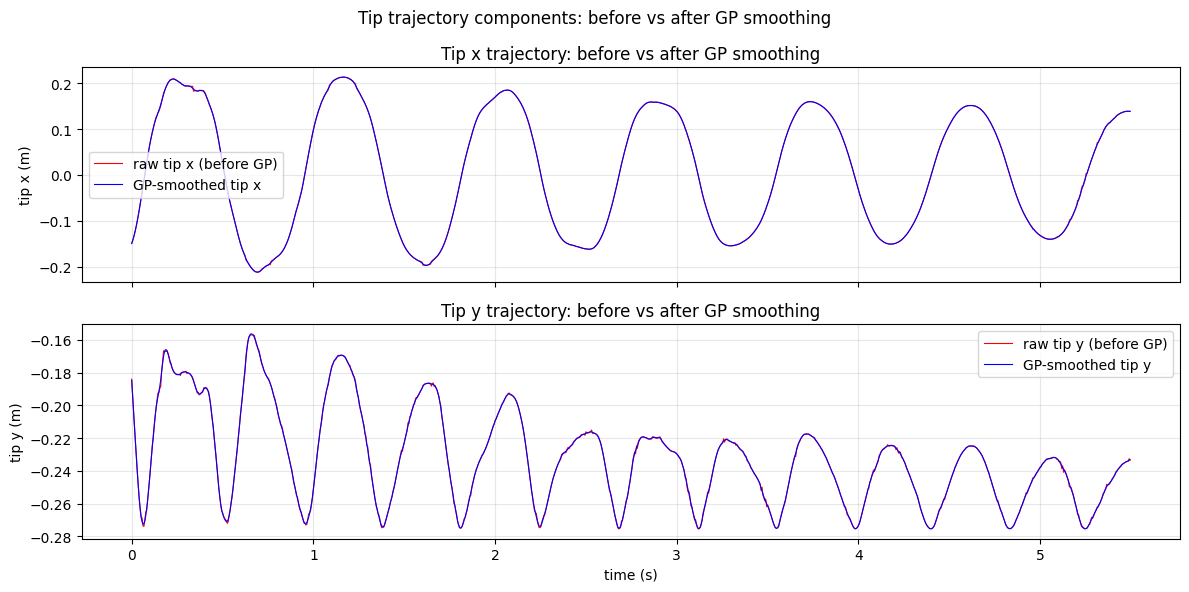

In [223]:
# plot tip positions from all_pts_px (before GP overwrote x_m) and after GP smoothing over time  on top of each other
fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=100, sharex=True)
axes[0].plot(t_frames, tip_x_raw, 'r-', lw=0.8, label='raw tip x (before GP)')
axes[0].plot(t_query, x_smooth[:, -1], 'b-', lw=0.8, label='GP-smoothed tip x')     
axes[0].set_ylabel('tip x (m)'); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Tip x trajectory: before vs after GP smoothing')
axes[0].legend()
axes[1].plot(t_frames, tip_y_raw, 'r-', lw=0.8, label='raw tip y (before GP)')
axes[1].plot(t_query, y_smooth[:, -1], 'b-', lw=0.8, label='GP-smoothed tip y')
axes[1].set_ylabel('tip y (m)'); axes[1].grid(True, alpha=0.3)
axes[1].set_title('Tip y trajectory: before vs after GP smoothing')
axes[1].set_xlabel('time (s)')
axes[1].legend()
plt.suptitle('Tip trajectory components: before vs after GP smoothing')
plt.tight_layout()
plt.show()      

## Step 6c — Spatial GP comparison (optional)

Adds spatial GPs (Matérn-5/2, arc-length `s → x,y` per frame, queried at 500 dense
arc-length points) exactly as in `real_data_reconstruction.ipynb` Step 4a.5.
Then recomputes θ from the dense spatial GP curves and fits the same temporal GPs.

Results are stored in `_sp_x_smooth`, `_sp_y_smooth`, `_sp_theta_smooth`, `_sp_thetadot`.
A side-by-side comparison plot is produced. The main pipeline variables (`x_m`, `y_m`,
`theta`, `xdot`, `ydot`, `thetadot`) are **not overwritten** — run the last cell in
this step to switch to the spatial-GP path if the comparison shows it is better.


Fitting spatial GPs: 2 × 1067 raw frame-GPs (26 pts → 500 pts) ...
  spatial GP: frame 0/1067
  spatial GP: frame 100/1067
  spatial GP: frame 200/1067
  spatial GP: frame 300/1067
  spatial GP: frame 400/1067
  spatial GP: frame 500/1067
  spatial GP: frame 600/1067
  spatial GP: frame 700/1067
  spatial GP: frame 800/1067
  spatial GP: frame 900/1067
  spatial GP: frame 1000/1067
Spatial GPs done.
Branch alignment: mean offset = 0.0000 rad  (0.0°)  → applied to _sp_theta_at_frames
theta (spatial GP) range: [-3.177, 0.056] rad  (-182.0° to 3.2°)
Fitting temporal θ-GPs on spatial-GP-derived θ ...
  θ temporal GP: seg 0/24
  θ temporal GP: seg 5/24
  θ temporal GP: seg 10/24
  θ temporal GP: seg 15/24
  θ temporal GP: seg 20/24
Spatial-GP path θ̇ range: [-38.183, 32.141] rad/s
Current path      θ̇ range: [-37.978, 41.585] rad/s


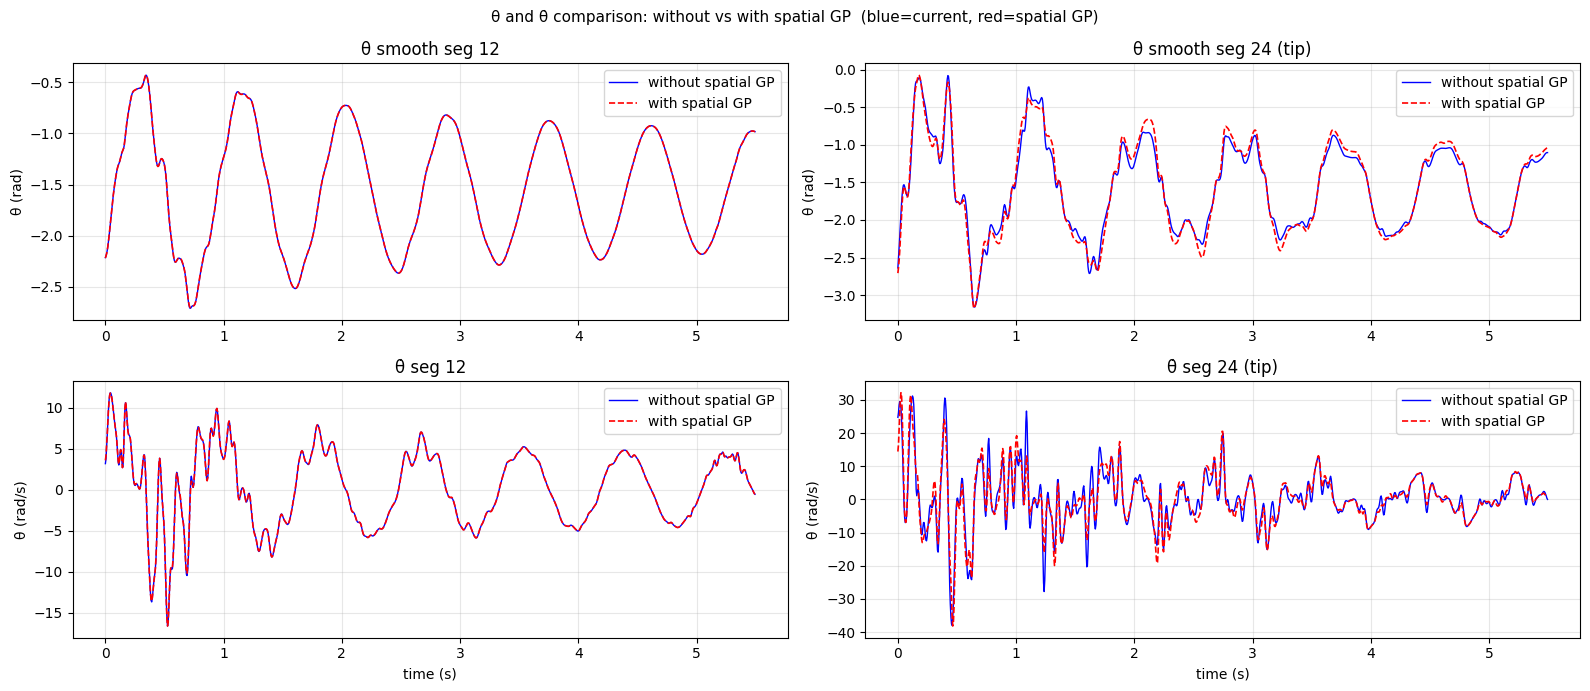

In [224]:
# ── Step 6c: Spatial GP per frame (Matérn-5/2, s → x,y) ────────────────────
# Mirrors real_data_reconstruction.ipynb Step 4a.5.
# For each frame: fit GP on arc-length s → (x, y) using N_OUT nodes,
# query at N_SP=500 dense arc-length points → smooth rod shape.
# Then compute θ from dense points (same as Step 4e in reconstruction).

N_SP   = 500    # dense arc-length points for spatial GP query
_s_raw = np.linspace(0, L0, N_OUT)          # arc-length of N_OUT nodes
_s_den = np.linspace(0, L0, N_SP)           # dense query points
_s_raw_col = _s_raw.reshape(-1, 1)
_s_den_col = _s_den.reshape(-1, 1)

# Arc-length midpoints for subsampling θ back to N segments
_s_angles   = (_s_den[:-1] + _s_den[1:]) / 2          # (N_SP-1,) midpoints
_s_node_mid = (_s_raw[:-1] + _s_raw[1:])   / 2        # (N,) segment midpoints
_seg_idx    = np.array([np.argmin(np.abs(_s_angles - _s_node_mid[k]))
                        for k in range(N)])

_k_sp = _Matern(length_scale=L0/4, length_scale_bounds=(L0/20, L0), nu=2.5)

# Spatial GP operates on original raw frames (before TARGET_FPS upsampling)
# t_kept_orig holds the original camera timestamps (set in the convert cell, never overwritten)
n_raw = len(all_pts_px)
_t_col_sp_raw = t_kept_orig.reshape(-1, 1)   # original camera timestamps (937 frames)
# Query at upsampled t_kept so output matches n_kept
_t_col_sp = t_kept.reshape(-1, 1)

print(f"Fitting spatial GPs: 2 × {n_raw} raw frame-GPs ({N_OUT} pts → {N_SP} pts) ...")
_sp_theta_at_frames = np.zeros((n_raw, N))

# Recompute raw pixel-converted positions (before temporal GP overwrote x_m, y_m)
x_m_raw = np.zeros((n_raw, N_OUT))
y_m_raw = np.zeros((n_raw, N_OUT))
_clamp_col, _clamp_row = float(CLAMP_PX[0]), float(CLAMP_PX[1])
for _i, _lp in enumerate(all_pts_px):
    x_m_raw[_i] = ( _lp[:, 0] - _clamp_col) / PIXELS_PER_METRE
    y_m_raw[_i] = -(_lp[:, 1] - _clamp_row) / PIXELS_PER_METRE
x_m_raw[:, 0] = 0.0
y_m_raw[:, 0] = 0.0

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for _i in range(n_raw):
        _gp_sx = _GPR(kernel=_k_sp, alpha=1e-4, normalize_y=True)
        _gp_sy = _GPR(kernel=_k_sp, alpha=1e-4, normalize_y=True)
        _gp_sx.fit(_s_raw_col[1:], x_m_raw[_i, 1:])
        _gp_sy.fit(_s_raw_col[1:], y_m_raw[_i, 1:])

        _x_sp = np.concatenate([[0.0], _gp_sx.predict(_s_den_col[1:]).ravel()])
        _y_sp = np.concatenate([[0.0], _gp_sy.predict(_s_den_col[1:]).ravel()])

        _th_raw    = np.arctan2(np.diff(_y_sp), np.diff(_x_sp))
        _th_unwrap = np.unwrap(_th_raw)
        _shift     = np.round((_th_raw[0] - _th_unwrap[0]) / (2*np.pi)) * 2*np.pi # anchor base angle
        _sp_theta_at_frames[_i] = (_th_unwrap + _shift)[_seg_idx]

        if _i % 100 == 0:
            print(f"  spatial GP: frame {_i}/{n_raw}")

print("Spatial GPs done.")

for seg in range(N):
    _sp_theta_at_frames[:, seg] = np.unwrap(_sp_theta_at_frames[:, seg])

# ── Align spatial-GP θ branch to match temporal-GP θ (Step 6b) ──────────────
# Both represent the same physical angle but may differ by ±2πk due to unwrap.
# Use the first raw frame as anchor: compute offset and round to nearest 2π.
_ref_theta_frame0 = theta_raw[0, :]          # temporal-GP raw θ at frame 0 (N segs)
_sp_theta_frame0  = _sp_theta_at_frames[0,:] # spatial-GP θ at frame 0 (N segs)
_branch_offset = np.round((_ref_theta_frame0 - _sp_theta_frame0) / (2*np.pi)) * 2*np.pi
_branch_offset_mean = np.mean(_branch_offset)
_sp_theta_at_frames += _branch_offset_mean
print(f"Branch alignment: mean offset = {_branch_offset_mean:.4f} rad  "
      f"({np.degrees(_branch_offset_mean):.1f}°)  → applied to _sp_theta_at_frames")

print(f"theta (spatial GP) range: [{_sp_theta_at_frames.min():.3f}, "
      f"{_sp_theta_at_frames.max():.3f}] rad  "
      f"({np.degrees(_sp_theta_at_frames.min()):.1f}° to "
      f"{np.degrees(_sp_theta_at_frames.max()):.1f}°)")

print(f"Fitting temporal θ-GPs on spatial-GP-derived θ ...")
_sp_theta_smooth = np.zeros((n_kept, N))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for seg in range(N):
        _gp_th = _GPR(kernel=_k_th, alpha=1e-4, normalize_y=True)
        _gp_th.fit(_t_col_sp_raw, _sp_theta_at_frames[:, seg])
        _sp_theta_smooth[:, seg] = _gp_th.predict(_t_col_sp)
        if seg % 5 == 0:
            print(f"  θ temporal GP: seg {seg}/{N-1}")

_sp_thetadot = np.gradient(_sp_theta_smooth, dt, axis=0)
_sp_thetadot[:, 0] = 0.0

print(f"Spatial-GP path θ̇ range: [{_sp_thetadot.min():.3f}, {_sp_thetadot.max():.3f}] rad/s")
print(f"Current path      θ̇ range: [{thetadot.min():.3f}, {thetadot.max():.3f}] rad/s")

_mid = N // 2
fig, axes = plt.subplots(2, 2, figsize=(16, 7), dpi=100)

axes[0, 0].plot(t_kept, theta[:, _mid],            "b-",  lw=1,   label="without spatial GP")
axes[0, 0].plot(t_kept, _sp_theta_smooth[:, _mid], "r--", lw=1.2, label="with spatial GP")
axes[0, 0].set_title(f"θ smooth seg {_mid}"); axes[0, 0].set_ylabel("θ (rad)")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_kept, theta[:, -1],              "b-",  lw=1,   label="without spatial GP")
axes[0, 1].plot(t_kept, _sp_theta_smooth[:, -1],   "r--", lw=1.2, label="with spatial GP")
axes[0, 1].set_title(f"θ smooth seg {N-1} (tip)"); axes[0, 1].set_ylabel("θ (rad)")
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t_kept, thetadot[:, _mid],     "b-",  lw=1,   label="without spatial GP")
axes[1, 0].plot(t_kept, _sp_thetadot[:, _mid], "r--", lw=1.2, label="with spatial GP")
axes[1, 0].set_title(f"θ̇ seg {_mid}"); axes[1, 0].set_ylabel("θ̇ (rad/s)")
axes[1, 0].set_xlabel("time (s)"); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_kept, thetadot[:, -1],       "b-",  lw=1,   label="without spatial GP")
axes[1, 1].plot(t_kept, _sp_thetadot[:, -1],   "r--", lw=1.2, label="with spatial GP")
axes[1, 1].set_title(f"θ̇ seg {N-1} (tip)"); axes[1, 1].set_ylabel("θ̇ (rad/s)")
axes[1, 1].set_xlabel("time (s)"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("θ and θ̇ comparison: without vs with spatial GP  (blue=current, red=spatial GP)",
             fontsize=11)
plt.tight_layout()
plt.show() 



In [228]:
# _base = 0
# fig, axes = plt.subplots(2, 2, figsize=(16, 7), dpi=100)

# axes[0, 0].plot(t_kept, theta[:, 1],            "b-",  lw=1,   label="without spatial GP")
# axes[0, 0].plot(t_kept, _sp_theta_smooth[:, 1], "r--", lw=1.2, label="with spatial GP")
# axes[0, 0].set_title(f"θ smooth seg {_base}"); axes[0, 0].set_ylabel("θ (rad)")
# axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1].plot(t_kept, theta[:, -1],              "b-",  lw=1,   label="without spatial GP")
# axes[0, 1].plot(t_kept, _sp_theta_smooth[:, -1],   "r--", lw=1.2, label="with spatial GP")
# axes[0, 1].set_title(f"θ smooth seg {N-1} (tip)"); axes[0, 1].set_ylabel("θ (rad)")
# axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# # 
# axes[1, 0].plot(t_kept, thetadot[:, 1],     "b-",  lw=1,   label="without spatial GP")
# axes[1, 0].plot(t_kept, _sp_thetadot[:, 1], "r--", lw=1.2, label="with spatial GP")
# axes[1, 0].set_title(f"θ̇ seg {_base}"); axes[1, 0].set_ylabel("θ̇ (rad/s)")
# axes[1, 0].set_xlabel("time (s)"); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# axes[1, 1].plot(t_kept, thetadot[:, -1],       "b-",  lw=1,   label="without spatial GP")
# axes[1, 1].plot(t_kept, _sp_thetadot[:, -1],   "r--", lw=1.2, label="with spatial GP")
# axes[1, 1].set_title(f"θ̇ seg {N-1} (tip)"); axes[1, 1].set_ylabel("θ̇ (rad/s)")
# axes[1, 1].set_xlabel("time (s)"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# plt.suptitle("θ and θ̇ comparison: without vs with spatial GP  (blue=current, red=spatial GP)",
#              fontsize=11)
# plt.tight_layout()
# plt.show() 


### Switch to spatial-GP path (optional)

Run this cell **only** if the comparison above shows the spatial-GP path is better.
It overwrites `theta`, `thetadot` with the spatial-GP versions and recomputes momenta.


In [229]:
# Overwrite theta and thetadot with the spatial-GP-derived versions
theta    = _sp_theta_smooth
thetadot = _sp_thetadot

# enforce clamp angle to be constant (no rotation at clamp)
theta[:, 0] = np.mean(theta[:, 0])
thetadot[:, 0] = 0.0

print('Switched to spatial-GP theta and thetadot.')
print(f'  θ̇ range: [{thetadot.min():.3f}, {thetadot.max():.3f}] rad/s')
print('Re-run Step 7 (momenta) to propagate the change.')


Switched to spatial-GP theta and thetadot.
  θ̇ range: [-38.183, 32.141] rad/s
Re-run Step 7 (momenta) to propagate the change.


## Step 7 — Compute θ, velocities, and momenta

Uses the same convention as `real_data_reconstruction.ipynb`:
- θ from `arctan2(dy, dx)` of consecutive node pairs
- ẋ, ẏ, θ̇ by `np.gradient` (central difference on the GP-smoothed positions)
- p_x = ρA·ẋ,  p_y = ρA·ẏ,  p_θ = ρI·θ̇

In [25]:
FPS

500

N=25  N_OUT=26  (N+1 nodes, N segments)
p_x    range: [-2.7950e-01, 3.2116e-01]
p_y    range: [-2.2661e-01, 1.6120e-01]
p_θ    range: [-9.6596e-06, 8.1310e-06]
p_x_dot    range: [-4.4836e+00, 4.2229e+00]
p_y_dot    range: [-1.0901e+01, 1.1012e+01]
p_θ_dot    range: [-4.6281e-04, 5.9299e-04]


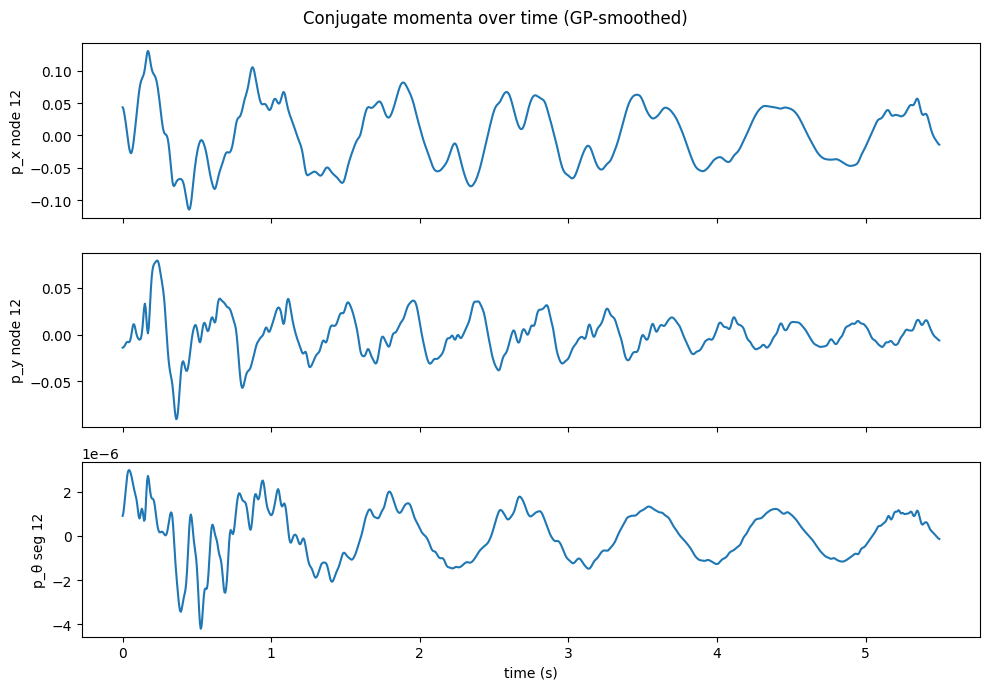

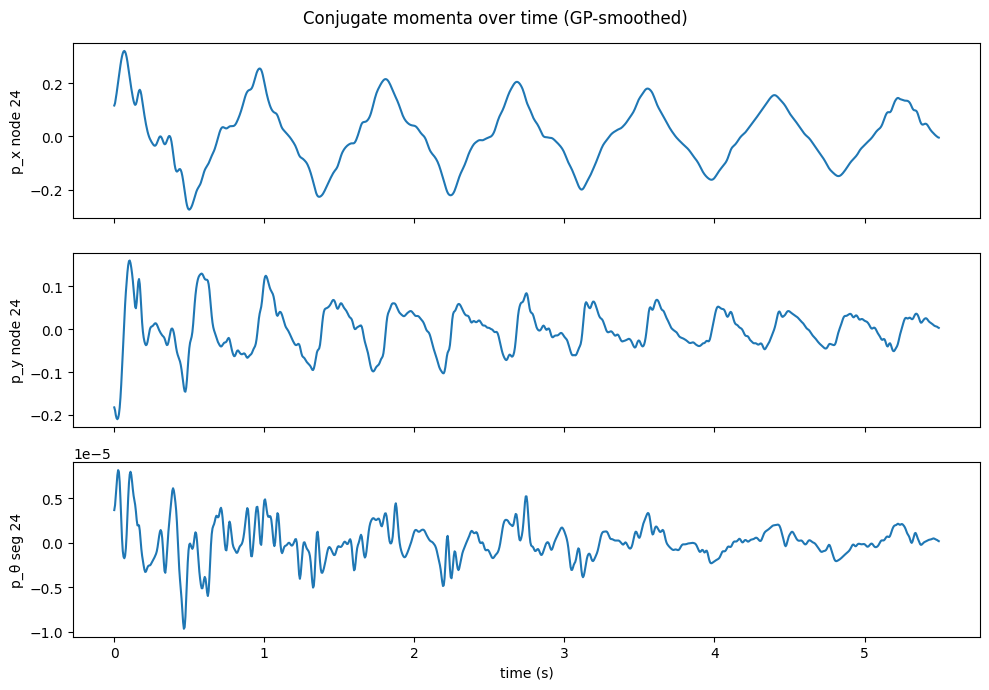

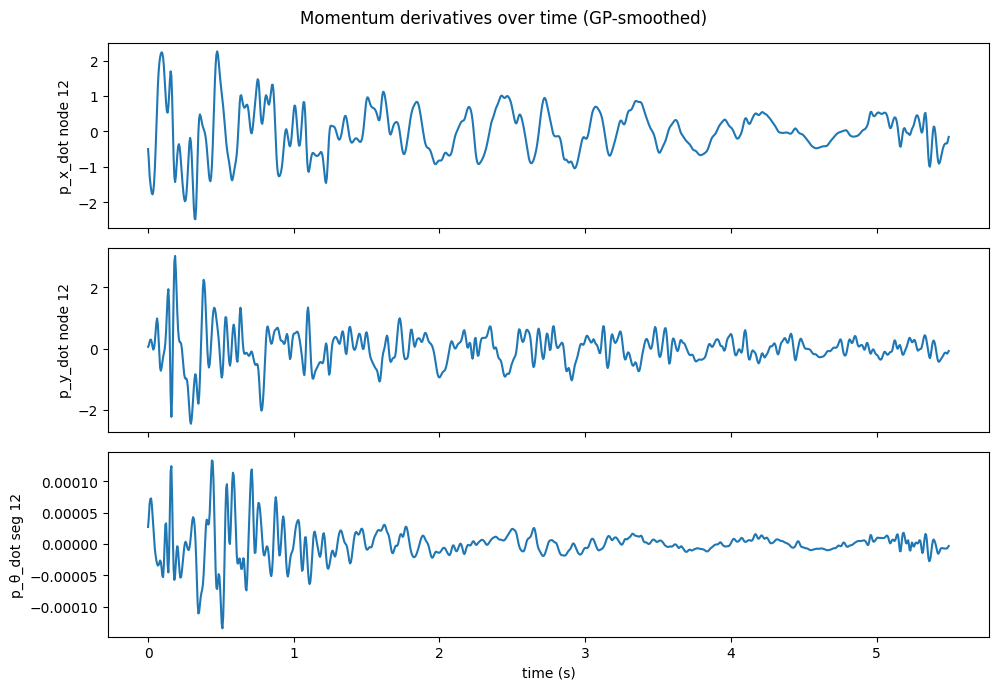

In [231]:
# x_m, y_m, theta, xdot, ydot, thetadot already computed in Step 6b (GP-smoothed)

# ── Momenta ──────────────────────────────────────────────────────────────────
p_x     = rho * A * xdot        # (n_kept, N+1)
p_y     = rho * A * ydot
p_theta = rho * I * thetadot    # (n_kept, N)

p_x[:, 0]     = 0.0
p_y[:, 0]     = 0.0
p_theta[:, 0] = 0.0


# ── Momentum derivatives (needed for z_dot) ─────────────────────────────────
# np.gradient on GP-smoothed momenta — same approach as reconstruction notebook

p_x_dot     = np.gradient(p_x,     1.0/TARGET_FPS, axis=0)
p_y_dot     = np.gradient(p_y,     1.0/TARGET_FPS, axis=0)
p_theta_dot = np.gradient(p_theta, 1.0/TARGET_FPS, axis=0)

# Enforce zero at clamped base
p_x_dot[:, 0]     = 0.0
p_y_dot[:, 0]     = 0.0
p_theta_dot[:, 0] = 0.0

# ── Quick check: ranges and sample plots ─────────────────────────────────────

print(f'N={N}  N_OUT={N_OUT}  (N+1 nodes, N segments)')
print(f'p_x    range: [{p_x.min():.4e}, {p_x.max():.4e}]')
print(f'p_y    range: [{p_y.min():.4e}, {p_y.max():.4e}]')
print(f'p_θ    range: [{p_theta.min():.4e}, {p_theta.max():.4e}]')

# ── Quick check: Momentum derivatives ranges and sample plots ─────────────────────────────────────
print(f'p_x_dot    range: [{p_x_dot.min():.4e}, {p_x_dot.max():.4e}]')
print(f'p_y_dot    range: [{p_y_dot.min():.4e}, {p_y_dot.max():.4e}]')
print(f'p_θ_dot    range: [{p_theta_dot.min():.4e}, {p_theta_dot.max():.4e}]')



fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
_mid = N // 2
axes[0].plot(t_kept, p_x[:, _mid]); axes[0].set_ylabel(f'p_x node {_mid}')
axes[1].plot(t_kept, p_y[:, _mid]); axes[1].set_ylabel(f'p_y node {_mid}')
axes[2].plot(t_kept, p_theta[:, _mid]); axes[2].set_ylabel(f'p_θ seg {_mid}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Conjugate momenta over time (GP-smoothed)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
Tip = N -1 
axes[0].plot(t_kept, p_x[:, Tip]); axes[0].set_ylabel(f'p_x node {Tip}')
axes[1].plot(t_kept, p_y[:, Tip]); axes[1].set_ylabel(f'p_y node {Tip}')
axes[2].plot(t_kept, p_theta[:, Tip]); axes[2].set_ylabel(f'p_θ seg {Tip}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Conjugate momenta over time (GP-smoothed)')
plt.tight_layout()
plt.show()

# plot the  Momentum derivatives
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
axes[0].plot(t_kept, p_x_dot[:, _mid]); axes[0].set_ylabel(f'p_x_dot node {_mid}')
axes[1].plot(t_kept, p_y_dot[:, _mid]); axes[1].set_ylabel(f'p_y_dot node {_mid}')
axes[2].plot(t_kept, p_theta_dot[:, _mid]); axes[2].set_ylabel(f'p_θ_dot seg {_mid}')
axes[2].set_xlabel('time (s)')
fig.suptitle('Momentum derivatives over time (GP-smoothed)')
plt.tight_layout()
plt.show()

## Step 7b — Damping estimate from tip oscillation

Estimates modal damping ratio ξ and the PH model coefficient ζ_PH from the
log-decrement of the tip x-trajectory.

**Important:** Use `ζ_PH` (not ξ) in MATLAB Step 10 and the Verlet simulation.
ξ and ζ_PH differ by ~2·ρI·ω_n ≈ several orders of magnitude.



Positive peaks
  Peaks found: 6  |  Amplitudes: [0.1842 0.1884 0.1601 0.134  0.1349 0.1265]
  delta=0.07522  xi=0.01197  T_d=0.8784s  omega_n=7.1539 rad/s
  ζ_PH = 2·ρI·ω_n·ξ = 4.333e-08

Negative peaks (troughs)
  Peaks found: 6  |  Amplitudes: [0.2373 0.2226 0.1873 0.1798 0.1761 0.1655]
  delta=0.07203  xi=0.01146  T_d=0.8732s  omega_n=7.1961 rad/s
  ζ_PH = 2·ρI·ω_n·ξ = 4.174e-08

──────────────────────────────────────────────────
  xi_mean      = 0.01172
  omega_n_mean = 7.1750 rad/s  (f = 1.142 Hz)
  ζ_PH_mean    = 4.254e-08  ← use this in MATLAB & Verlet
──────────────────────────────────────────────────
  (simulation default ζ=1e-9 is near-undamped; ζ_PH tells you how far off that is)


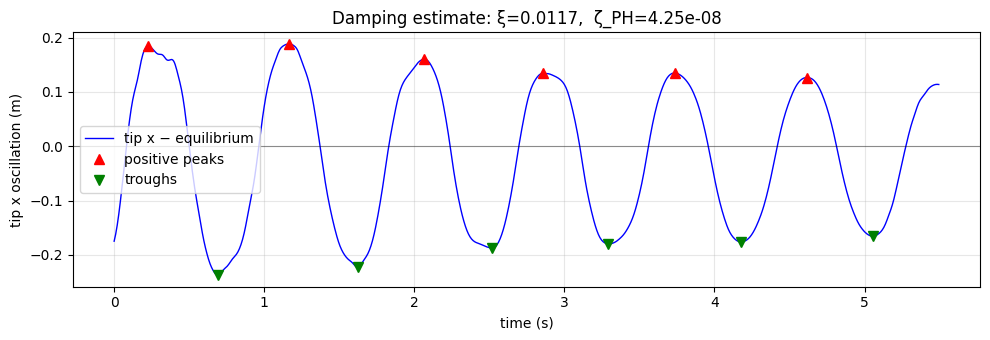

In [232]:
from scipy.signal import find_peaks

tip_x  = x_m[:, -1]                          # tip x in metres
tip_eq = np.mean(tip_x[int(0.8 * len(tip_x)):])
tip_signal = tip_x - tip_eq

est_period_frames = max(1, int(FPS * 0.3))   # min spacing ≈ 0.3 s
peak_prominence   = 0.03                    # metres; lower if no peaks found

def _damping_from_peaks(A, t_peaks, label):
    valid = A > 0
    A, t_peaks = A[valid], t_peaks[valid]
    print(f'\n{label}')
    print(f'  Peaks found: {len(A)}  |  Amplitudes: {np.round(A, 4)}')
    if len(A) < 3:
        print('  Not enough peaks for reliable estimate.')
        return None
    n_cycles = len(A) - 1
    delta    = np.log(A[0] / A[-1]) / n_cycles
    xi       = delta / np.sqrt((2*np.pi)**2 + delta**2)
    T_d      = np.mean(np.diff(t_peaks))
    omega_d  = 2 * np.pi / T_d
    omega_n  = omega_d / np.sqrt(max(1 - xi**2, 1e-12))
    zeta_PH  = 2 * rho * I * omega_n * xi
    print(f'  delta={delta:.5f}  xi={xi:.5f}  T_d={T_d:.4f}s  omega_n={omega_n:.4f} rad/s')
    print(f'  ζ_PH = 2·ρI·ω_n·ξ = {zeta_PH:.3e}')
    return dict(A=A, t_peaks=t_peaks, xi=xi, omega_n=omega_n, zeta_PH=zeta_PH)

# Positive peaks
pk_pos, _ = find_peaks( tip_signal, distance=est_period_frames, prominence=peak_prominence)
# Negative troughs
pk_neg, _ = find_peaks(-tip_signal, distance=est_period_frames, prominence=peak_prominence)

res_pos = _damping_from_peaks( tip_signal[pk_pos], t_kept[pk_pos], 'Positive peaks')
res_neg = _damping_from_peaks(-tip_signal[pk_neg], t_kept[pk_neg], 'Negative peaks (troughs)')

valid = [r for r in [res_pos, res_neg] if r is not None]
if valid:
    xi_mean       = np.mean([r['xi']       for r in valid])
    omega_n_mean  = np.mean([r['omega_n']  for r in valid])
    zeta_PH_mean  = np.mean([r['zeta_PH']  for r in valid])
    print(f'\n{"─"*50}')
    print(f'  xi_mean      = {xi_mean:.5f}')
    print(f'  omega_n_mean = {omega_n_mean:.4f} rad/s  (f = {omega_n_mean/(2*np.pi):.3f} Hz)')
    print(f'  ζ_PH_mean    = {zeta_PH_mean:.3e}  ← use this in MATLAB & Verlet')
    print(f'{"─"*50}')
    print(f'  (simulation default ζ=1e-9 is near-undamped; ζ_PH tells you how far off that is)')

    fig, ax = plt.subplots(figsize=(10, 3.5), dpi=100)
    ax.plot(t_kept, tip_signal, 'b-', lw=1, label='tip x − equilibrium')
    if res_pos:
        ax.plot(res_pos['t_peaks'], np.interp(res_pos['t_peaks'], t_kept, tip_signal),
                'r^', ms=7, label='positive peaks')
    if res_neg:
        ax.plot(res_neg['t_peaks'], np.interp(res_neg['t_peaks'], t_kept, tip_signal),
                'gv', ms=7, label='troughs')
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set_xlabel('time (s)'); ax.set_ylabel('tip x oscillation (m)')
    ax.set_title(f'Damping estimate: ξ={xi_mean:.4f},  ζ_PH={zeta_PH_mean:.2e}')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('\nNo peaks detected — lower peak_prominence or check tip trajectory.')
    fig, ax = plt.subplots(figsize=(10, 3), dpi=100)
    ax.plot(t_kept, tip_signal); ax.set_xlabel('time (s)'); ax.set_ylabel('tip x − eq (m)')
    ax.set_title('Tip signal (no peaks found)'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## Step 7c — q_y elastic deformation diagnostic

Estimates the internal y-force `q_y` from the PH inverse and checks whether the
recording has enough elastic bending for GPR training.

| Metric | Threshold | Simulation reference |
|--------|-----------|----------------------|
| q_y temporal std | > 5e-2 ✅, 2e-2–5e-2 ⚠️, < 2e-2 ❌ | 9.5e-2 |
| spatial/temporal ratio | < 1.5 ✅, < 2.5 ⚠️, > 2.5 ❌ | ~1.2 |


  q_y ELASTIC DEFORMATION DIAGNOSTIC
  (1067 frames @ 194 Hz)
  gravity ρAg             = 1.1908e+00 N/m
  p_y_dot std             = 8.6211e-01
  gravity/signal ratio    = 1.38x  (sim: ~2x)

  q_y spatial std         = 9.6670e-02  (gravity-driven)
  q_y temporal std        = 9.4307e-02  (elastic signal)
  spatial/temporal ratio  = 1.03x  (sim: ~1.2x)

  Elastic deformation:  ✅ GOOD
  GPR fit quality:      ✅ GPR will fit well

  Simulation reference: temporal_std=9.5e-02, ratio=1.19x


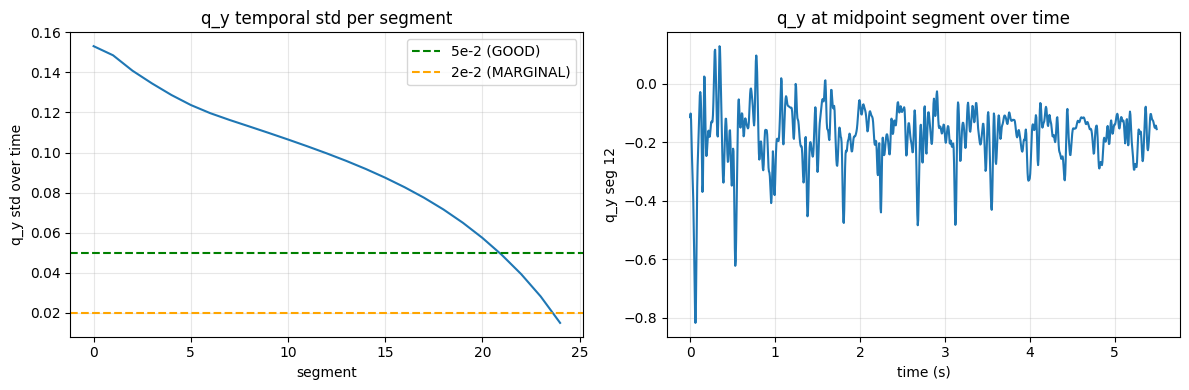

In [233]:
from scipy.integrate import cumulative_trapezoid as _ctrap

_N       = N
_ds      = L0 / _N
_gravity = rho * A * 9.80665   # N/m

# p_y_dot via np.gradient (same as MATLAB will see from z_dot)
_p_y_dot = np.gradient(p_y, 1.0/FPS, axis=0)
_p_y_dot[:, 0] = 0.0

_dH_no_grav = -_p_y_dot - _gravity   # (n_frames, N+1) — elastic component only

# Integrate from tip to base (cumulative_trapezoid in reverse)
_q_nodes = np.zeros((n_kept, _N + 1))
for _k in range(n_kept):
    _q_nodes[_k, :] = _ctrap(_dH_no_grav[_k, :][::-1], dx=_ds, initial=0)[::-1]
_q_seg = _q_nodes[:, :_N]   # N segments

_spatial_std  = _q_seg.mean(axis=0).std()
_temporal_std = _q_seg.std(axis=0).mean()
_ratio        = _spatial_std / (_temporal_std + 1e-12)
_grav_ratio   = _gravity / (_p_y_dot.std() + 1e-12)

_e_status = ('✅ GOOD'      if _temporal_std > 5e-2 else
             '⚠️  MARGINAL' if _temporal_std > 2e-2 else
             '❌ POOR')
_g_status = ('✅ GPR will fit well' if _ratio < 1.5 else
             '⚠️  GPR may struggle' if _ratio < 2.5 else
             '❌ GPR will fail to fit')

print('=' * 55)
print('  q_y ELASTIC DEFORMATION DIAGNOSTIC')
print(f'  ({n_kept} frames @ {FPS:.0f} Hz)')
print('=' * 55)
print(f'  gravity ρAg             = {_gravity:.4e} N/m')
print(f'  p_y_dot std             = {_p_y_dot.std():.4e}')
print(f'  gravity/signal ratio    = {_grav_ratio:.2f}x  (sim: ~2x)')
print()
print(f'  q_y spatial std         = {_spatial_std:.4e}  (gravity-driven)')
print(f'  q_y temporal std        = {_temporal_std:.4e}  (elastic signal)')
print(f'  spatial/temporal ratio  = {_ratio:.2f}x  (sim: ~1.2x)')
print()
print(f'  Elastic deformation:  {_e_status}')
print(f'  GPR fit quality:      {_g_status}')
print()
print(f'  Simulation reference: temporal_std=9.5e-02, ratio=1.19x')
if _temporal_std < 5e-2:
    _need = 9.5e-2 / (_temporal_std + 1e-12)
    print(f'  Rod needs {_need:.1f}x more elastic bending to match simulation.')
    print(f'  Record with rod bent into C/S curves, not just pendulum swing.')
print('=' * 55)

# Plot q_y temporal std per node
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)
axes[0].plot(_q_seg.std(axis=0))
axes[0].axhline(5e-2, color='g',  ls='--', label='5e-2 (GOOD)')
axes[0].axhline(2e-2, color='orange', ls='--', label='2e-2 (MARGINAL)')
axes[0].set_xlabel('segment'); axes[0].set_ylabel('q_y std over time')
axes[0].set_title('q_y temporal std per segment'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

_mid = _N // 2
axes[1].plot(t_kept, _q_seg[:, _mid])
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel(f'q_y seg {_mid}')
axes[1].set_title(f'q_y at midpoint segment over time'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Step 8 — Assemble state matrix z and save

Layout matches `cosserat_GPR_pipeline_real_data.m`:
```
z = [x(N+1), y(N+1), θ(N), p_x(N+1), p_y(N+1), p_θ(N)]
```
Total columns = 4(N+1) + 2N = 6N+4.

In [234]:


# ── Assemble z ───────────────────────────────────────────────────────────────
z = np.hstack([
    x_m,      # cols 0      .. N       (N+1)
    y_m,      # cols N+1    .. 2N+1    (N+1)
    theta,    # cols 2N+2   .. 3N+1    (N)
    p_x,      # cols 3N+2   .. 4N+2    (N+1)
    p_y,      # cols 4N+3   .. 5N+3    (N+1)
    p_theta,  # cols 5N+4   .. 6N+3    (N)
])

# ── Assemble z_dot ───────────────────────────────────────────────────────────
# Enforce clamped boundary on all velocity/derivative components
xdot[:, 0]        = 0.0
ydot[:, 0]        = 0.0
thetadot[:, 0]    = 0.0

z_dot = np.hstack([
    xdot,         # cols 0      .. N       (N+1)
    ydot,         # cols N+1    .. 2N+1    (N+1)
    thetadot,     # cols 2N+2   .. 3N+1    (N)
    p_x_dot,      # cols 3N+2   .. 4N+2    (N+1)
    p_y_dot,      # cols 4N+3   .. 5N+3    (N+1)
    p_theta_dot,  # cols 5N+4   .. 6N+3    (N)
])

expected_cols = 4*(N+1) + 2*N
assert z.shape     == (n_kept, expected_cols), \
    f'z shape {z.shape} != expected ({n_kept}, {expected_cols})'
assert z_dot.shape == (n_kept, expected_cols), \
    f'z_dot shape {z_dot.shape} != expected ({n_kept}, {expected_cols})'

t_out = t_kept.reshape(-1, 1)

print(f'z shape:     {z.shape}  (frames × state_dim={expected_cols})')
print(f'z_dot shape: {z_dot.shape}')
print(f't range:     [{t_out.min():.3f}, {t_out.max():.3f}] s')
print(f'State dim breakdown: 4×{N+1} + 2×{N} = {expected_cols}')
print()
print('Column index check (same for z and z_dot):')
print(f'  x  / ẋ:      0 … {N}')
print(f'  y  / ẏ:      {N+1} … {2*(N+1)-1}')
print(f'  θ  / θ̇:      {2*(N+1)} … {2*(N+1)+N-1}')
print(f'  p_x / ṗ_x:  {2*(N+1)+N} … {3*(N+1)+N-1}')
print(f'  p_y / ṗ_y:  {3*(N+1)+N} … {4*(N+1)+N-1}')
print(f'  p_θ / ṗ_θ:  {4*(N+1)+N} … {4*(N+1)+2*N-1}')

# ── Boundary condition check ─────────────────────────────────────────────────
print(f'\n=== Boundary conditions ===')
print(f'max |x[:,0]|     = {np.abs(z[:,0]).max():.2e}   (expect 0)')
print(f'max |y[:,0]|     = {np.abs(z[:,N+1]).max():.2e}  (expect 0)')
print(f'max |p_x[:,0]|   = {np.abs(z[:,2*(N+1)+N]).max():.2e}  (expect 0)')
print(f'max |p_y[:,0]|   = {np.abs(z[:,3*(N+1)+N]).max():.2e}  (expect 0)')
print(f'max |xdot[:,0]|  = {np.abs(z_dot[:,0]).max():.2e}  (expect 0)')
print(f'max |ydot[:,0]|  = {np.abs(z_dot[:,N+1]).max():.2e}  (expect 0)')

# ── Save z ───────────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(OUT_MAT), exist_ok=True)


savemat(OUT_MAT, {
    'z':   z,
    't':   t_out,
    'N':   float(N),
    'L0':  L0,
    'rho': rho,
    'A':   A,
    'I':   I,
    'fps': FPS,
    'pixels_per_metre': PIXELS_PER_METRE,
})
print(f'\nSaved z:     {OUT_MAT}')

# ── Save z_dot ───────────────────────────────────────────────────────────────
OUT_MAT_DOT = OUT_MAT.replace('.mat', '_dot.mat')
savemat(OUT_MAT_DOT, {
    'z_dot': z_dot,
    't':     t_out,
    'N':     float(N),
    'D':     float(z_dot.shape[1]),
    'L0':    L0,
    'rho':   rho,
    'A':     A,
    'I':     I,
    'fps':   FPS,
})
print(f'Saved z_dot: {OUT_MAT_DOT}')
print(f'  N={N}  L0={L0}  rho={rho}  A={A:.4e}  I={I:.4e}')


z shape:     (1067, 154)  (frames × state_dim=154)
z_dot shape: (1067, 154)
t range:     [0.000, 5.495] s
State dim breakdown: 4×26 + 2×25 = 154

Column index check (same for z and z_dot):
  x  / ẋ:      0 … 25
  y  / ẏ:      26 … 51
  θ  / θ̇:      52 … 76
  p_x / ṗ_x:  77 … 102
  p_y / ṗ_y:  103 … 128
  p_θ / ṗ_θ:  129 … 153

=== Boundary conditions ===
max |x[:,0]|     = 0.00e+00   (expect 0)
max |y[:,0]|     = 0.00e+00  (expect 0)
max |p_x[:,0]|   = 0.00e+00  (expect 0)
max |p_y[:,0]|   = 0.00e+00  (expect 0)
max |xdot[:,0]|  = 0.00e+00  (expect 0)
max |ydot[:,0]|  = 0.00e+00  (expect 0)

Saved z:     Processed_data/cosserat_real_data.mat
Saved z_dot: Processed_data/cosserat_real_data_dot.mat
  N=25  L0=0.28  rho=2428.6  A=5.0000e-05  I=1.0417e-10


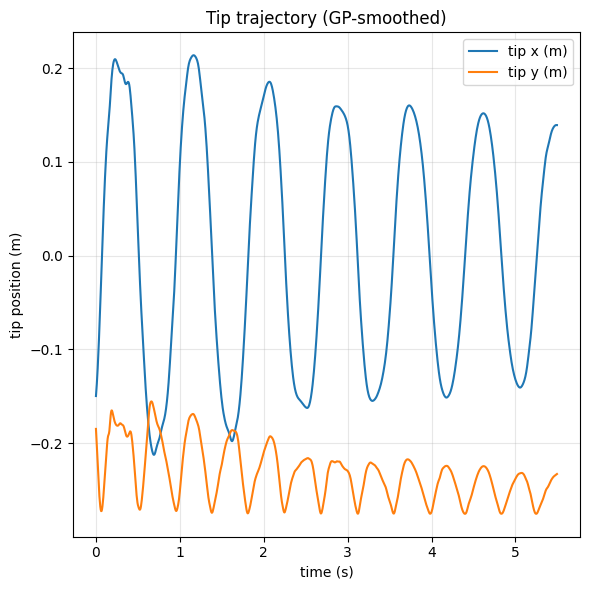

tip_y mean: -0.2322 m
tip_y std:  0.0291 m
tip_x std:  0.1314 m


In [204]:
## plot tip trajectory and check it looks reasonable
tip_x = z[:, N]        # last x node (col N, 0-based)
tip_y = z[:, 2*N + 1]  # last y node (col 2N+1, 0-based)

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.plot(t_out, tip_x, label='tip x (m)')    
ax.plot(t_out, tip_y, label='tip y (m)')
ax.set_xlabel('time (s)'); ax.set_ylabel('tip position (m)')
ax.set_title('Tip trajectory (GP-smoothed)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()  

print(f'tip_y mean: {tip_y.mean():.4f} m')
print(f'tip_y std:  {tip_y.std():.4f} m')
print(f'tip_x std:  {tip_x.std():.4f} m')



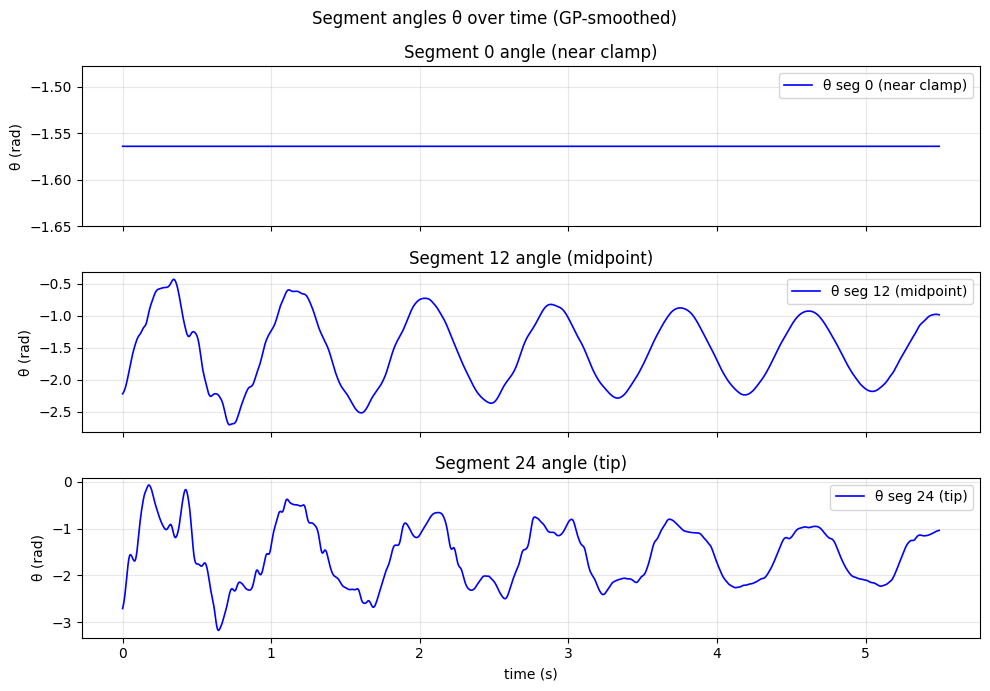

In [235]:
# plote theta of segment 1 (closest to clamp) over time
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, dpi=100)
axes[0].plot(t_kept, theta[:, 0], 'b-', lw=1.2, label='θ seg 0 (near clamp)')
axes[0].set_title('Segment 0 angle (near clamp)'); axes[0].set_ylabel('θ (rad)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(t_kept, theta[:, N//2], 'b-', lw=1.2, label=f'θ seg {N//2} (midpoint)')
axes[1].set_title(f'Segment {N//2} angle (midpoint)'); axes[1].set_ylabel('θ (rad)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(t_kept, theta[:, -1], 'b-', lw=1.2, label=f'θ seg {N-1} (tip)')
axes[2].set_title(f'Segment {N-1} angle (tip)'); axes[2].set_ylabel('θ (rad)'); axes[2].set_xlabel('time (s)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle('Segment angles θ over time (GP-smoothed)')
plt.tight_layout(); plt.show()  


Clamped node state variables (should be near zero):
  x:     max abs = 0.00e+00 m
  y:     max abs = 0.00e+00 m
  p_x:   max abs = 0.00e+00
  p_y:   max abs = 0.00e+00
  θ seg0: max abs = 1.56e+00 rad
  p_θ seg0: max abs = 0.00e+00


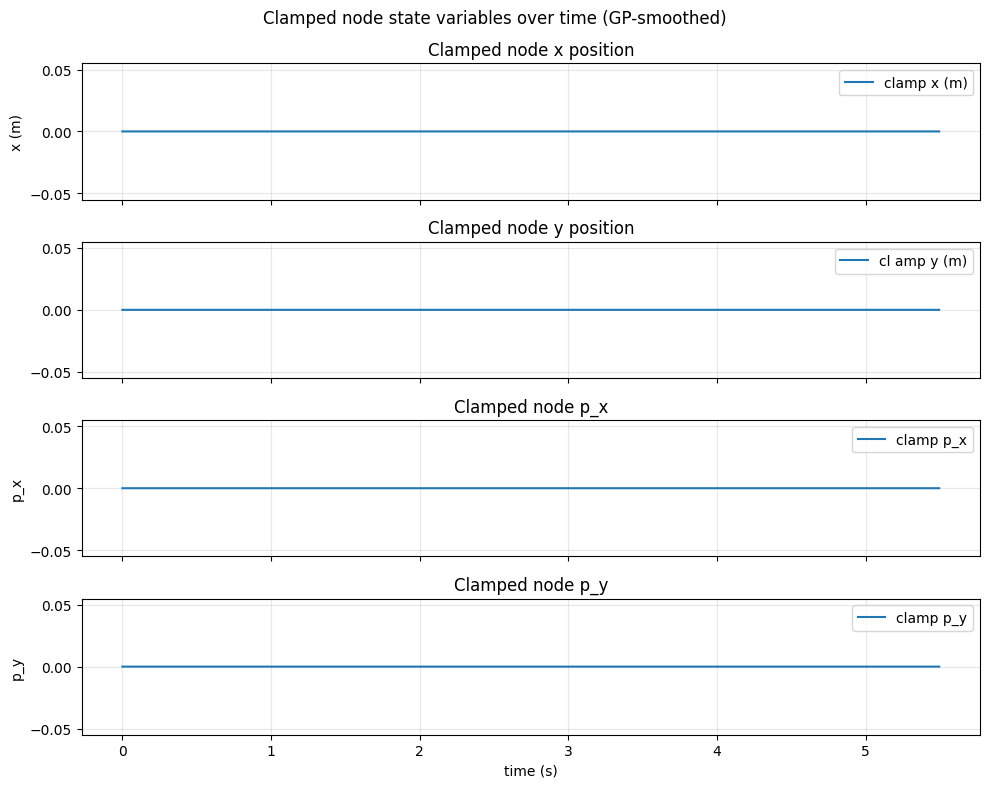

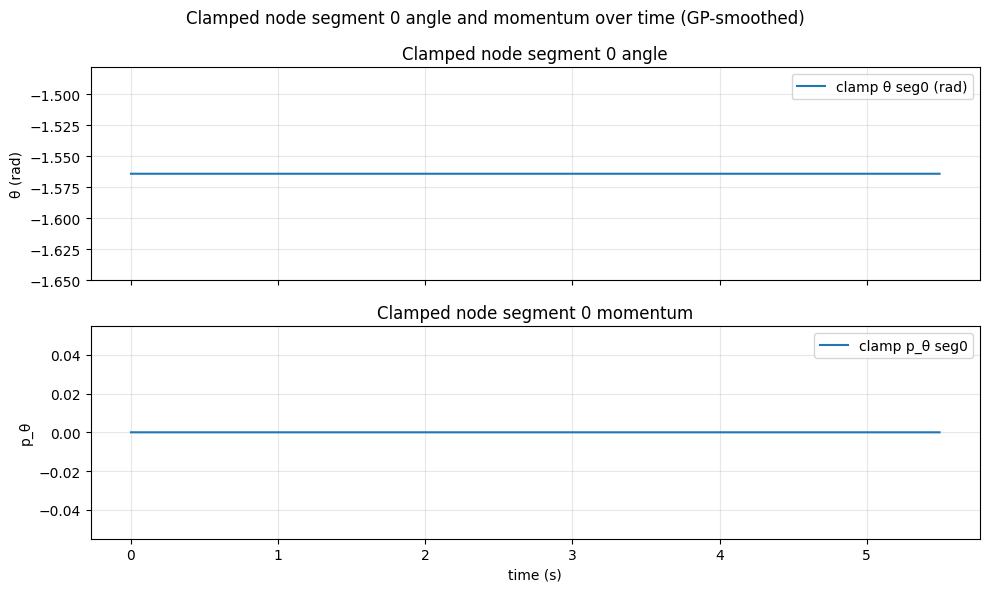


Clamped node state derivatives (should be near zero):
  x_dot:     max abs = 0.00e+00 m/s
  y_dot:     max abs = 0.00e+00 m/s
  p_x_dot:   max abs = 0.00e+00 m/s
  p_y_dot:   max abs = 0.00e+00 m/s
  θ_dot seg0: max abs = 0.00e+00 rad/s
  p_θ_dot seg0: max abs = 0.00e+00


In [236]:
# print and plot all state variables over time for the clamped node (col 0 for x, col N+1 for y, col 2(N+1)+N for p_x, col 3(N+1)+N for p_y), and print and plot theta of the first segment (col 2(N+1) for theta, col 4(N+1)+N for p_theta) to check they are all zero as expected for the clamped boundary condition   
clamp_x = z[:, 0]
clamp_y = z[:, N+1]         
clamp_p_x = z[:, 2*(N+1)+N]
clamp_p_y = z[:, 3*(N+1)+N]
clamp_theta = z[:, 2*(N+1)]
clamp_p_theta = z[:, 4*(N+1)+N]
print(f'\nClamped node state variables (should be near zero):')
print(f'  x:     max abs = {np.abs(clamp_x).max():.2e} m')
print(f'  y:     max abs = {np.abs(clamp_y).max():.2e} m')
print(f'  p_x:   max abs = {np.abs(clamp_p_x).max():.2e}')
print(f'  p_y:   max abs = {np.abs(clamp_p_y).max():.2e}')
print(f'  θ seg0: max abs = {np.abs(clamp_theta).max():.2e} rad')
print(f'  p_θ seg0: max abs = {np.abs(clamp_p_theta).max():.2e}')   



fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, dpi=100)
axes[0].plot(t_kept, clamp_x, label='clamp x (m)')
axes[0].set_title('Clamped node x position'); axes[0].set_ylabel('x (m)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(t_kept, clamp_y, label='cl amp y (m)')
axes[1].set_title('Clamped node y position'); axes[1].set_ylabel                        
('y (m)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(t_kept, clamp_p_x, label='clamp p_x')
axes[2].set_title('Clamped node p_x'); axes[2].set_ylabel('p_x'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[3].plot(t_kept, clamp_p_y, label='clamp p_y')
axes[3].set_title('Clamped node p_y'); axes[3].set_ylabel('p_y'); axes[3].set_xlabel('time (s)'); axes[3].legend(); axes[3].grid(True, alpha=0.3)
plt.suptitle('Clamped node state variables over time (GP-smoothed)')
plt.tight_layout(); plt.show()  

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, dpi=100)
axes[0].plot(t_kept, clamp_theta, label='clamp θ seg0 (rad)')
axes[0].set_title('Clamped node segment 0 angle'); axes[0].set_ylabel('θ (rad)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(t_kept, clamp_p_theta, label='clamp p_θ seg0')
axes[1].set_title('Clamped node segment 0 momentum'); axes[1].set_ylabel('p_θ'); axes[1].set_xlabel('time (s)'); 
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Clamped node segment 0 angle and momentum over time (GP-smoothed)')
plt.tight_layout(); plt.show()  


# do the same for the derivatives of the state variables at the clamped node (col 0 for x, col N+1 for y, col 2(N+1)+N for p_x, col 3(N+1)+N for p_y), and print and plot the derivative of theta of the first segment (col 2(N+1) for theta, col 4(N+1)+N for p_theta) to check they are all zero as expected for the clamped boundary condition
clamp_x_dot = z_dot[:, 0]
clamp_y_dot = z_dot[:, N+1]
clamp_p_x_dot = z_dot[:, 2*(N+1)+N]
clamp_p_y_dot = z_dot[:, 3*(N+1)+N]
clamp_theta_dot = z_dot[:, 2*(N+1)]
clamp_p_theta_dot = z_dot[:, 4*(N+1)+N]
print(f'\nClamped node state derivatives (should be near zero):')
print(f'  x_dot:     max abs = {np.abs(clamp_x_dot).max():.2e} m/s')
print(f'  y_dot:     max abs = {np.abs(clamp_y_dot).max():.2e} m/s')    
print(f'  p_x_dot:   max abs = {np.abs(clamp_p_x_dot).max():.2e} m/s')
print(f'  p_y_dot:   max abs = {np.abs(clamp_p_y_dot).max():.2e} m/s')
print(f'  θ_dot seg0: max abs = {np.abs(clamp_theta_dot).max():.2e} rad/s')
print(f'  p_θ_dot seg0: max abs = {np.abs(clamp_p_theta_dot).max():.2e}')               


## Step 9 — Write annotated output video

Renders the original frames with the detected sub-pixel centreline overlaid.
Green line = centreline, green square = clamp (node 0), red triangle = tip.

In [237]:
_cap, _tmp = _open_video(VIDEO_PATH)
_w = int(_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
_h = int(_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

_tmp_avi = OUT_VIDEO_H264.replace('.mp4', '_tmp.avi')
fourcc   = cv2.VideoWriter_fourcc(*'XVID')
_writer  = cv2.VideoWriter(_tmp_avi, fourcc, int(FPS), (_w, _h))

# all_pts_px_raw is the raw pixel positions before any arc length normalization or smoothing (used for overlay to show original data)
# _lp_lookup = {frame_idxs[_i]: all_pts_px_raw[_i] for _i in range(len(frame_idxs))}

# all_pts_px is the smoothed pixel positions after temporal GP (used for overlay to show smoothed rod shape)
_lp_lookup = {frame_idxs[_i]: all_pts_px[_i] for _i in range(len(frame_idxs))}


_cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
for _fi in range(frame_start, frame_end):
    _ret, _fr = _cap.read()
    if not _ret: break
    if _fi in _lp_lookup:
        _lp = _lp_lookup[_fi].astype(np.int32).copy()
        _lp[0] = [int(round(CLAMP_PX[0])), int(round(CLAMP_PX[1]))]  # fix clamp jitter
        cv2.polylines(_fr, [_lp.reshape(-1,1,2)], False, (0,255,0), 2, cv2.LINE_AA)
        cv2.circle(_fr, tuple(_lp[0]),  10, (0,200,0),  -1)
        cv2.circle(_fr, tuple(_lp[-1]), 10, (0,60,255), -1)
        # Draw every 4th node
        for _pt in _lp[::4]:
            cv2.circle(_fr, tuple(_pt), 4, (255,100,0), -1)
    _writer.write(_fr)

_cap.release()
_writer.release()
if _tmp: os.unlink(_tmp)

subprocess.run(['ffmpeg', '-y', '-i', _tmp_avi,
                '-c:v', 'libx264', '-pix_fmt', 'yuv420p', OUT_VIDEO_H264],
               capture_output=True)
os.unlink(_tmp_avi)
print(f'Saved: {OUT_VIDEO_H264}')

Saved: Processed_videos/centerline_subpixel_h264.mp4


## Step 10 — Comparison: sub-pixel vs skeletonization arc-length

Load the arc-length CSV from the old pipeline (if available) and plot side-by-side.

Sub-pixel pipeline:
  arc mean  = 27.722 cm
  arc std   = 1.917 mm
  arc range = 11.440 mm

No old pipeline CSV found at ../../../Data/Real_data/arc_length_skeleton_old.csv
To compare, rename the skeleton pipeline CSV to that path and re-run this cell.


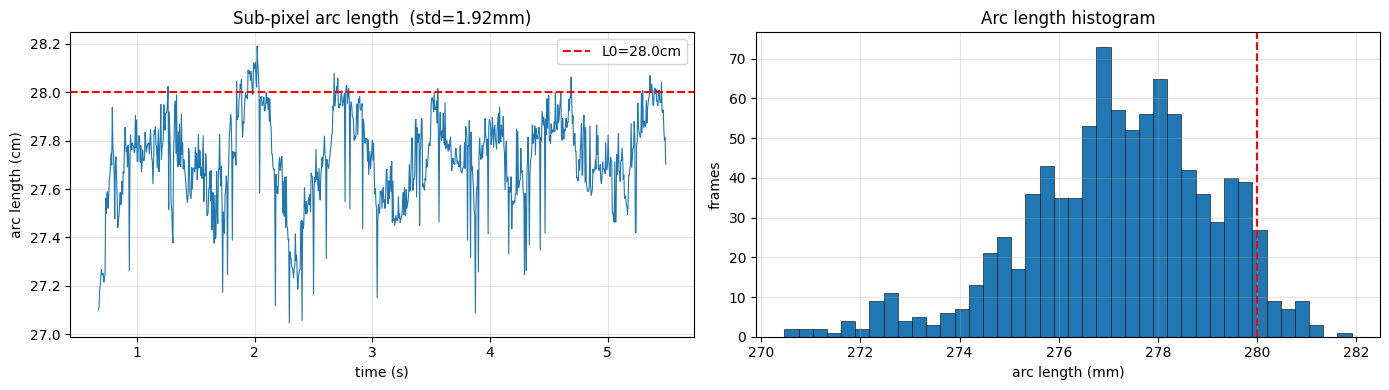

In [22]:
# Sub-pixel result (current pipeline)
arc_subpx_m = arc_arr / PIXELS_PER_METRE

print(f'Sub-pixel pipeline:')
print(f'  arc mean  = {arc_subpx_m.mean()*100:.3f} cm')
print(f'  arc std   = {arc_subpx_m.std()*1000:.3f} mm')
print(f'  arc range = {(arc_subpx_m.max()-arc_subpx_m.min())*1000:.3f} mm')

# Try to load old skeletonization result for comparison
_old_csv = OUT_ARC_CSV.replace('arc_length_per_frame', 'arc_length_skeleton_old')
if os.path.exists(_old_csv):
    _old = np.loadtxt(_old_csv)
    _old_arc_m = _old[:, 2]
    print(f'\nSkeletonization pipeline (old):')
    print(f'  arc mean  = {_old_arc_m.mean()*100:.3f} cm')
    print(f'  arc std   = {_old_arc_m.std()*1000:.3f} mm')
    print(f'  arc range = {(_old_arc_m.max()-_old_arc_m.min())*1000:.3f} mm')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
    axes[0].plot(arc_subpx_m*100, lw=0.8, label=f'sub-pixel (std={arc_subpx_m.std()*1000:.1f}mm)')
    axes[0].plot(np.linspace(0, len(arc_subpx_m)-1, len(_old_arc_m)),
                 _old_arc_m*100, lw=0.8, alpha=0.7, label=f'skeleton (std={_old_arc_m.std()*1000:.1f}mm)')
    axes[0].axhline(L0*100, color='r', ls='--', label=f'L0={L0*100:.1f}cm')
    axes[0].set_ylabel('arc length (cm)'); axes[0].set_xlabel('frame')
    axes[0].set_title('Arc length over time'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].hist(arc_subpx_m*1000, bins=40, alpha=0.7, label='sub-pixel', edgecolor='k', lw=0.3)
    axes[1].hist(_old_arc_m*1000, bins=40, alpha=0.7, label='skeleton', edgecolor='k', lw=0.3)
    axes[1].axvline(L0*1000, color='r', ls='--')
    axes[1].set_xlabel('arc length (mm)'); axes[1].set_ylabel('frames')
    axes[1].set_title('Arc length histogram'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f'\nNo old pipeline CSV found at {_old_csv}')
    print('To compare, rename the skeleton pipeline CSV to that path and re-run this cell.')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
    axes[0].plot(t_frames, arc_subpx_m*100, lw=0.8)
    axes[0].axhline(L0*100, color='r', ls='--', label=f'L0={L0*100:.1f}cm')
    axes[0].set_ylabel('arc length (cm)'); axes[0].set_xlabel('time (s)')
    axes[0].set_title(f'Sub-pixel arc length  (std={arc_subpx_m.std()*1000:.2f}mm)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].hist(arc_subpx_m*1000, bins=40, edgecolor='k', lw=0.4)
    axes[1].axvline(L0*1000, color='r', ls='--')
    axes[1].set_xlabel('arc length (mm)'); axes[1].set_ylabel('frames')
    axes[1].set_title('Arc length histogram'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## Step 11 — 3D surface plots: x(t, node) and y(t, node)

plotly not installed — showing matplotlib heatmaps only


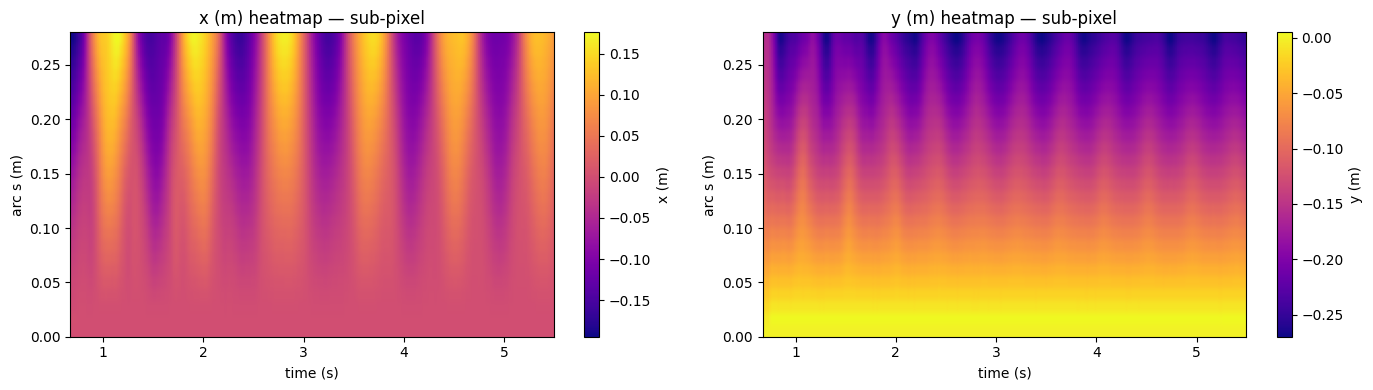

In [46]:
try:
    import plotly.graph_objects as go
    _has_plotly = True
except ImportError:
    _has_plotly = False
    print('plotly not installed — showing matplotlib heatmaps only')

_stride_t = max(1, n_kept // 200)
_t_ax     = t_frames[::_stride_t]
_s_ax     = np.linspace(0, L0, N_OUT)
_X        = x_m[::_stride_t, :]    # (n_t, N_OUT)
_Y        = y_m[::_stride_t, :]

if _has_plotly:
    for _Z, _cs, _lbl, _title in [
        (_X.T, 'RdBu',   'x (m)', 'x(s, t) — sub-pixel'),
        (_Y.T, 'plasma', 'y (m)', 'y(s, t) — sub-pixel'),
    ]:
        _kw = dict(cmid=0) if _cs == 'RdBu' else {}
        _fig = go.Figure(go.Surface(
            x=_t_ax, y=_s_ax, z=_Z,
            colorscale=_cs, colorbar=dict(title=_lbl), **_kw
        ))
        _fig.update_layout(
            title=_title,
            scene=dict(xaxis_title='time (s)', yaxis_title='arc s (m)', zaxis_title=_lbl,
                       camera=dict(eye=dict(x=1.8, y=-1.8, z=0.9))),
            width=750, height=500, margin=dict(l=0,r=0,t=40,b=0)
        )
        _fig.show()

# Matplotlib heatmaps (always shown)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
for _ax, _Z, _lbl in [(axes[0], _X.T, 'x (m)'), (axes[1], _Y.T, 'y (m)')]:
    _im = _ax.imshow(_Z, aspect='auto', origin='lower',
                     extent=[_t_ax[0], _t_ax[-1], 0, L0], cmap='plasma')
    plt.colorbar(_im, ax=_ax, label=_lbl)
    _ax.set_xlabel('time (s)'); _ax.set_ylabel('arc s (m)')
    _ax.set_title(f'{_lbl} heatmap — sub-pixel')
plt.tight_layout()
plt.show()